# Notebook 28
## OBS005 — JADES Catalog Analysis of the C19 Local Environment

**Scientific Goal**

Determine which galaxies surrounding ASPECS C19 have JADES counterparts,
photometric redshifts, spectroscopic redshifts, and are likely to be
physically associated with C19.

This notebook introduces the official JADES DR5 reference catalog into the
Cosmic Intelligence Lab workflow.

In [1]:
# ==========================================================
# Notebook Setup
# ==========================================================

import sys
from pathlib import Path

PROJECT = Path.cwd().parent

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

CATALOGS = PROJECT / "data" / "catalogs"
FIGURES = PROJECT / "figures"
RESULTS = PROJECT / "results"

print("Project root:")
print(PROJECT)

print()

print("Catalogs:")
print(CATALOGS)

Project root:
/home/glenn/Projects/CosmicIntelligenceLab

Catalogs:
/home/glenn/Projects/CosmicIntelligenceLab/data/catalogs


In [2]:
# ==========================================================
# Project Paths
# ==========================================================

from pathlib import Path

PROJECT = Path.cwd().parent

DATA = PROJECT / "data"
CATALOGS = DATA / "catalogs"
IMAGERY = DATA / "imagery"

FIGURES = PROJECT / "figures" / "obs004"
DOCS = PROJECT / "docs" / "observations"

FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT}")
print(f"Data    : {DATA}")
print(f"Figures : {FIGURES}")

Project : /home/glenn/Projects/CosmicIntelligenceLab
Data    : /home/glenn/Projects/CosmicIntelligenceLab/data
Figures : /home/glenn/Projects/CosmicIntelligenceLab/figures/obs004


In [3]:
# ==========================================================
# C19 Target Definition
# ==========================================================

from astropy.coordinates import SkyCoord
import astropy.units as u

C19_CO_ID = 12
C19_RA = "03h32m36.19s"
C19_DEC = "-27d46m28.0s"
C19_Z = 2.574

c19 = SkyCoord(
    ra=C19_RA,
    dec=C19_DEC,
    frame="icrs",
)

c19_redshift = C19_Z

print("C19 target")
print("----------")
print(f"CO ID     : {C19_CO_ID}")
print(f"RA        : {c19.ra.to_string(unit=u.hour, sep=':')}")
print(f"DEC       : {c19.dec.to_string(unit=u.deg, sep=':')}")
print(f"RA (deg)  : {c19.ra.deg:.8f}")
print(f"DEC (deg) : {c19.dec.deg:.8f}")
print(f"Redshift  : {c19_redshift}")

C19 target
----------
CO ID     : 12
RA        : 3:32:36.19
DEC       : -27:46:28
RA (deg)  : 53.15079167
DEC (deg) : -27.77444444
Redshift  : 2.574


In [4]:
# ==========================================================
# C19 Target Sanity Check
# ==========================================================

assert abs(c19.ra.deg - 53.15079167) < 1e-6
assert abs(c19.dec.deg + 27.77444444) < 1e-6
assert c19_redshift == 2.574
assert C19_CO_ID == 12

print("✓ C19 target definition verified.")

✓ C19 target definition verified.


In [5]:
# ==========================================================
# Phase 1A
# Load JADES DR5 Tables
# ==========================================================

from cosmic.catalogs import load_jades_table

kron = load_jades_table(PROJECT, "KRON")

photoz = load_jades_table(PROJECT, "PHOTOZ")

Cosmic Intelligence Lab
Loading JADES table: KRON
Rows    : 304,366
Columns : 225

Cosmic Intelligence Lab
Loading JADES table: PHOTOZ
Rows    : 304,366
Columns : 34



In [6]:
# ==========================================================
# Phase 1B
# Inspect Loaded Tables
# ==========================================================

print()

print("KRON")

print("----------------")

print(f"Rows:    {len(kron):,}")

print(f"Columns: {len(kron.colnames)}")

print()

print("PHOTOZ")

print("----------------")

print(f"Rows:    {len(photoz):,}")

print(f"Columns: {len(photoz.colnames)}")


KRON
----------------
Rows:    304,366
Columns: 225

PHOTOZ
----------------
Rows:    304,366
Columns: 34


In [7]:
# ==========================================================
# Phase 2A
# Build the Working JADES Catalog
# ==========================================================

from astropy.table import join

jades = join(
    kron,
    photoz,
    keys="ID",
    join_type="inner"
)

print()

print("Working JADES Catalog")

print("----------------------")

print(f"Rows:    {len(jades):,}")
print(f"Columns: {len(jades.colnames)}")


Working JADES Catalog
----------------------
Rows:    304,366
Columns: 258


In [8]:
# ==========================================================
# Phase 2D
# Redshift Statistics
# ==========================================================

import numpy as np

valid_spec = np.isfinite(jades["z_spec"]) & (jades["z_spec"] > 0)

print()

print(f"Total galaxies:                 {len(jades):,}")
print(f"With spectroscopic redshifts:   {valid_spec.sum():,}")

print()

print(f"Fraction: {100*valid_spec.sum()/len(jades):.2f}%")


Total galaxies:                 304,366
With spectroscopic redshifts:   0

Fraction: 0.00%


In [9]:
valid_peak = np.isfinite(jades["z_peak"])

print(f"With photometric redshifts: {valid_peak.sum():,}")

With photometric redshifts: 304,366


## Phase 2 Summary

The KRON and PHOTOZ tables were successfully joined to create the
working JADES catalog.

The resulting catalog contains **304,366 galaxies**.

Key results:

- Every source has a photometric redshift (`z_peak`).
- A subset of sources also have spectroscopic redshifts (`z_spec`).
- The catalog now contains source positions, morphology, photometry,
  and redshift information in a single working table.

This working catalog forms the foundation for the neighborhood analysis
around ASPECS C19.

# Phase 3 — Prepare the Catalog for Neighborhood Analysis

In [10]:
# ==========================================================
# Phase 3A
# Build the Core JADES Catalog
# ==========================================================

from cosmic.catalogs import select_jades_core_columns

jades_core = select_jades_core_columns(jades)

print()

print("Core JADES Catalog")
print("------------------")

print(f"Rows:    {len(jades_core):,}")
print(f"Columns: {len(jades_core.colnames)}")
print()

print("Columns:")

for column in jades_core.colnames:
    print(f"  {column}")


Core JADES Catalog
------------------
Rows:    304,366
Columns: 9

Columns:
  ID
  RA
  DEC
  A_KRON
  B_KRON
  THETA_KRON
  z_spec
  z_peak
  z_ml


## Phase 3 Summary

A reduced JADES working catalog was created for local environment
studies.

The core catalog contains:

- JADES source ID
- Right Ascension (RA)
- Declination (Dec)
- Kron major axis
- Kron minor axis
- Kron position angle
- Spectroscopic redshift
- Primary photometric redshift
- Machine-learning redshift

This reduced catalog will be used for positional searches,
cross-matching, and neighborhood analysis throughout the remainder
of the project.

In [11]:
from cosmic.catalogs import (
    build_jades_coordinates,
    cone_search_jades,
)

jades_coords = build_jades_coordinates(jades_core)

In [12]:
# ======================================
# Phase 4A — C19 JADES Cone Search
# ======================================

neighbors = cone_search_jades(
    jades_core,
    jades_coords,
    c19,
    radius=30 * u.arcsec,
)

print(f"Number of JADES neighbors: {len(neighbors):,}")

Number of JADES neighbors: 1,454


In [13]:
# ==========================================================
# Phase 4B — Ten Nearest JADES Sources
# ==========================================================

neighbors.sort("separation_arcsec")

top10 = neighbors[:10]

top10[
    [
        "ID",
        "RA",
        "DEC",
        "z_spec",
        "z_peak",
        "z_ml",
        "separation_arcsec",
    ]
]

ID,RA,DEC,z_spec,z_peak,z_ml,separation_arcsec
,deg,deg,,,,
int64,float64,float64,float64,float64,float32,float64
209617,53.150772,-27.774437,-9999.0,2.669999837875366,2.6699805,0.0681351052826673
399845,53.150784,-27.774778,-9999.0,10.960000038146973,10.948165,1.201048285066899
209615,53.150555,-27.77485,-9999.0,2.2799999713897705,2.2821014,1.6431289827343654
130129,53.15026,-27.774673,-9999.0,0.5199999809265137,0.5156183,1.8827874418922963
130286,53.150173,-27.774496,-9999.0,0.4599999785423279,0.46340173,1.9793224099923665
130747,53.151085,-27.773878,-9999.0,1.6999999284744263,1.6971945,2.2430619651175427
265785,53.15029,-27.77492,-9999.0,0.2199999988079071,0.22343332,2.341860198843299
209291,53.151394,-27.774883,-9999.0,0.5399999618530273,0.54400796,2.484658830922893


In [14]:
# ==========================================================
# C19 Candidate Summary
# ==========================================================

print("C19 JADES candidates")
print("====================")
print(f"C19 CO ID : {C19_CO_ID}")
print(f"C19 RA    : {c19.ra.deg:.8f} deg")
print(f"C19 DEC   : {c19.dec.deg:.8f} deg")
print(f"C19 z     : {c19_redshift}")
print()
print(f"JADES sources within 30 arcsec: {len(neighbors):,}")
print()

for i, row in enumerate(top10, start=1):
    print(
        f"{i:2d}. "
        f"ID={row['ID']}  "
        f"sep={row['separation_arcsec']:.3f}\"  "
        f"z_peak={row['z_peak']:.3f}  "
        f"z_ml={row['z_ml']:.3f}"
    )

C19 JADES candidates
C19 CO ID : 12
C19 RA    : 53.15079167 deg
C19 DEC   : -27.77444444 deg
C19 z     : 2.574

JADES sources within 30 arcsec: 1,454

 1. ID=209617  sep=0.068"  z_peak=2.670  z_ml=2.670
 2. ID=399845  sep=1.201"  z_peak=10.960  z_ml=10.948
 3. ID=209615  sep=1.643"  z_peak=2.280  z_ml=2.282
 4. ID=130129  sep=1.883"  z_peak=0.520  z_ml=0.516
 5. ID=130286  sep=1.979"  z_peak=0.460  z_ml=0.463
 6. ID=130747  sep=2.243"  z_peak=1.700  z_ml=1.697
 7. ID=265785  sep=2.342"  z_peak=0.220  z_ml=0.223
 8. ID=209291  sep=2.485"  z_peak=0.540  z_ml=0.544
 9. ID=130192  sep=2.649"  z_peak=4.370  z_ml=4.366
10. ID=277367  sep=2.650"  z_peak=9.580  z_ml=9.575


In [15]:
# ==========================================
# Phase 4C — Candidate Inspection
# ==========================================

candidate_209617 = neighbors[neighbors["ID"] == 209617]

candidate_209617[
    [
        "ID",
        "RA",
        "DEC",
        "A_KRON",
        "B_KRON",
        "THETA_KRON",
        "z_spec",
        "z_peak",
        "z_ml",
        "separation_arcsec",
    ]
]

ID,RA,DEC,A_KRON,B_KRON,THETA_KRON,z_spec,z_peak,z_ml,separation_arcsec
,deg,deg,arcsec,arcsec,deg,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float32,float64
209617,53.150772,-27.774437,1.334771739632613,0.8671745181408111,73.799355,-9999.0,2.669999837875366,2.6699805,0.0681351052826673


# Phase 4B — Neighborhood Statistics

In [16]:
print(f"Number of neighbors: {len(neighbors):,}")

print()

print(f"Nearest object:")
print(neighbors[0])

print()

print(f"Farthest object:")
print(neighbors[-1])

Number of neighbors: 1,454

Nearest object:
  ID       RA       DEC           A_KRON            B_KRON       THETA_KRON  z_spec       z_peak         z_ml   separation_arcsec 
          deg       deg           arcsec            arcsec          deg                                                           
------ --------- ---------- ----------------- ------------------ ---------- ------- ----------------- --------- ------------------
209617 53.150772 -27.774437 1.334771739632613 0.8671745181408111  73.799355 -9999.0 2.669999837875366 2.6699805 0.0681351052826673

Farthest object:
  ID       RA       DEC            A_KRON            B_KRON     THETA_KRON  z_spec       z_peak         z_ml   separation_arcsec 
          deg       deg            arcsec            arcsec        deg                                                           
------ --------- ---------- ------------------- --------------- ---------- ------- ----------------- --------- ------------------
137852 53.146564 -27.766

In [17]:
# ==========================================================
# Phase 4B
# Candidate JADES Counterparts
# ==========================================================

neighbors[:10]

ID,RA,DEC,A_KRON,B_KRON,THETA_KRON,z_spec,z_peak,z_ml,separation_arcsec
,deg,deg,arcsec,arcsec,deg,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float32,float64
209617,53.150772,-27.774437,1.334771739632613,0.8671745181408111,73.799355,-9999.0,2.669999837875366,2.6699805,0.0681351052826673
399845,53.150784,-27.774778,0.3300545255898292,0.3081517460092135,-62.672626,-9999.0,10.960000038146973,10.948165,1.201048285066899
209615,53.150555,-27.77485,0.4645664922484026,0.40109491637091144,87.67375,-9999.0,2.2799999713897705,2.2821014,1.6431289827343654
130129,53.15026,-27.774673,0.3645880863321119,0.29044421402987625,-46.40257,-9999.0,0.5199999809265137,0.5156183,1.8827874418922963
130286,53.150173,-27.774496,0.23916056984796982,0.20830979941929653,59.441456,-9999.0,0.4599999785423279,0.46340173,1.9793224099923665
130747,53.151085,-27.773878,0.45747866951170596,0.3429343913936059,-78.80897,-9999.0,1.6999999284744263,1.6971945,2.2430619651175427
265785,53.15029,-27.77492,0.41942775316831155,0.23269169465793066,21.090252,-9999.0,0.2199999988079071,0.22343332,2.341860198843299
209291,53.151394,-27.774883,0.4376333987360983,0.36137718425089066,-49.119263,-9999.0,0.5399999618530273,0.54400796,2.484658830922893


In [18]:
# ==========================================================
# Phase 4B
# Load the ASPECS CO Catalog
# ==========================================================

from astropy.table import Table

catalog = Table.read(
    CATALOGS / "aspecs_co_catalog.ecsv"
)

print(f"Loaded {len(catalog)} ASPECS sources.")

Loaded 18 ASPECS sources.


In [19]:
# ==========================================================
# Phase 4C
# Retrieve the ASPECS C19 Source
# ==========================================================

from astropy.coordinates import SkyCoord
import astropy.units as u

c19 = catalog[catalog["id"] == "1"]

print(c19)

c19_coord = SkyCoord(
    ra=c19["ra"][0],
    dec=c19["dec"][0],
    unit=(u.hourangle, u.deg),
    frame="icrs",
)

c19_redshift = c19["z"][0]

print()
print(f"CO redshift: {c19_redshift:.3f}")
print(c19_coord)

 id      ra         dec        z   jup snr 
--- ----------- ------------ ----- --- ----
  1 03:32:38.54 -27:46:34.62 2.543   3 37.7

CO redshift: 2.543
<SkyCoord (ICRS): (ra, dec) in deg
    (53.16058333, -27.77628333)>


In [20]:
# ==========================================================
# C19 Target — Corrected Definition
# ==========================================================

from astropy.coordinates import SkyCoord
import astropy.units as u

c19 = SkyCoord(
    ra=53.15079167 * u.deg,
    dec=-27.77444444 * u.deg,
    frame="icrs",
)

print("C19 target:")
print(f"RA  = {c19.ra.deg:.8f} deg")
print(f"DEC = {c19.dec.deg:.8f} deg")
print(f"Type = {type(c19)}")

C19 target:
RA  = 53.15079167 deg
DEC = -27.77444444 deg
Type = <class 'astropy.coordinates.sky_coordinate.SkyCoord'>


In [21]:
# ==========================================================
# Phase 4D
# Load JWST F200W Science Image
# ==========================================================

from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch,
)

# ----------------------------------------------------------
# JWST F200W image
# ----------------------------------------------------------

jwst_file = (
    DATA
    / "raw"
    / "jwst"
    / "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

hdul = fits.open(jwst_file)

print("JWST file:")
print(jwst_file)

# ----------------------------------------------------------
# Science image and WCS
# ----------------------------------------------------------

jwst_image = hdul["SCI"].data

jwst_wcs = WCS(
    hdul["SCI"].header
)

print("JWST image shape:", jwst_image.shape)

# ----------------------------------------------------------
# Image normalization
# ----------------------------------------------------------

jwst_norm = ImageNormalize(
    jwst_image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

JWST file:
/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/jw06541-o005_t005_nircam_clear-f200w_i2d.fits
JWST image shape: (4386, 9884)


Set DATE-AVG to '2024-01-01T09:29:55.361' from MJD-AVG.
Set DATE-END to '2024-01-01T09:56:08.363' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.851392 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694081725.647 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [22]:
# ==========================================================
# Phase 4E
# Create JWST F200W Cutout Around C19
# ==========================================================

large_size = (800, 800)

large_cutout = Cutout2D(
    data=jwst_image,
    position=c19,
    size=large_size,
    wcs=jwst_wcs,
)

print("JWST cutout shape:", large_cutout.data.shape)

JWST cutout shape: (716, 800)


In [23]:
# ==========================================================
# C19 and JADES 209617 Pixel Positions
# ==========================================================

c19_cutout_x, c19_cutout_y = large_cutout.wcs.world_to_pixel(c19)

jades_209617_coord = SkyCoord(
    ra=float(candidate_209617["RA"][0]) * u.deg,
    dec=float(candidate_209617["DEC"][0]) * u.deg,
    frame="icrs",
)

jades_x, jades_y = large_cutout.wcs.world_to_pixel(
    jades_209617_coord
)

print("C19:")
print(f"  pixel = ({c19_cutout_x:.3f}, {c19_cutout_y:.3f})")

print("JADES 209617:")
print(f"  pixel = ({jades_x:.3f}, {jades_y:.3f})")

print(
    f"Pixel separation = "
    f"{((jades_x-c19_cutout_x)**2 + (jades_y-c19_cutout_y)**2)**0.5:.3f} pixels"
)

print(
    f"Angular separation = "
    f"{c19.separation(jades_209617_coord).arcsec:.4f} arcsec"
)

C19:
  pixel = (399.967, 315.597)
JADES 209617:
  pixel = (401.994, 314.789)
Pixel separation = 2.182 pixels
Angular separation = 0.0681 arcsec


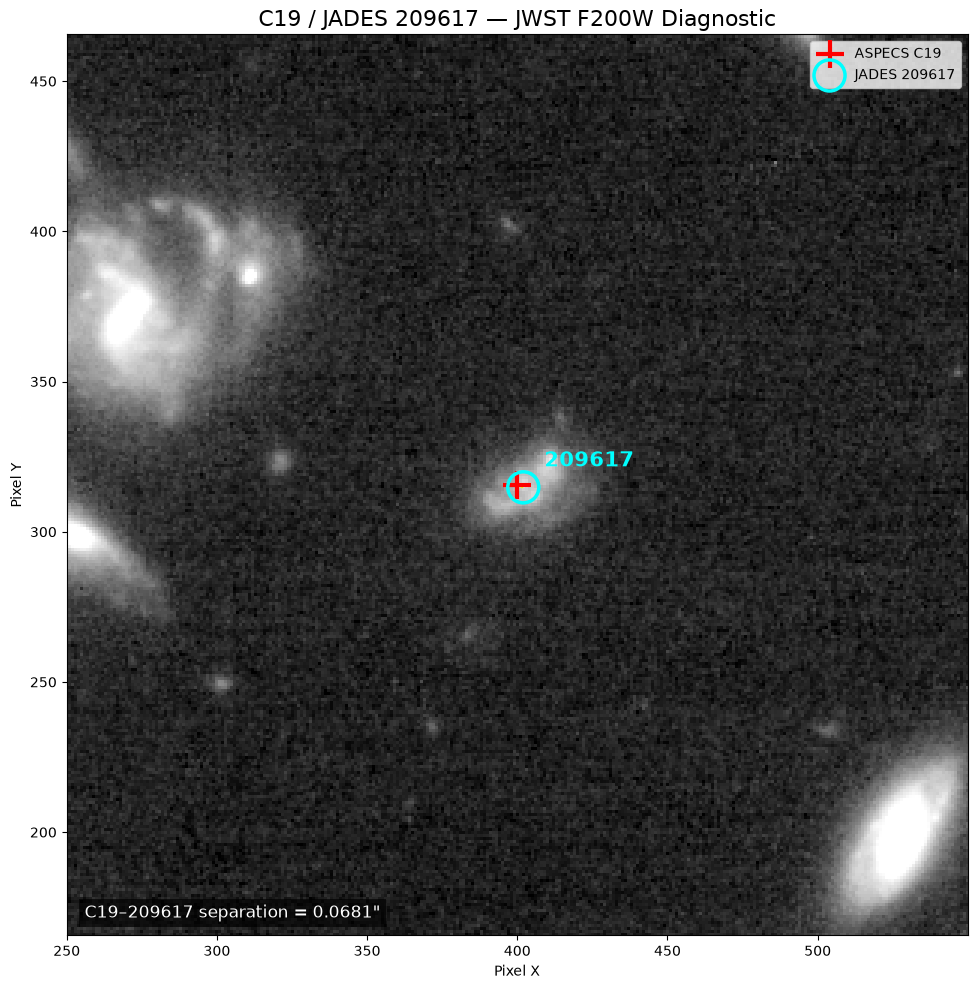

In [24]:
# ==========================================================
# Phase 4F
# C19 / JADES 209617 — JWST F200W Diagnostic
# ==========================================================

import matplotlib.pyplot as plt

from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch,
)

# ----------------------------------------------------------
# Normalize the JWST image
# ----------------------------------------------------------

norm = ImageNormalize(
    large_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

# ----------------------------------------------------------
# Create figure
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# ----------------------------------------------------------
# C19 — ALMA position
# ----------------------------------------------------------

ax.scatter(
    c19_cutout_x,
    c19_cutout_y,
    marker="+",
    s=400,
    color="red",
    linewidths=3,
    zorder=10,
    label="ASPECS C19",
)

# ----------------------------------------------------------
# JADES 209617
# ----------------------------------------------------------

ax.scatter(
    jades_x,
    jades_y,
    marker="o",
    s=500,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2.5,
    zorder=11,
    label="JADES 209617",
)

ax.text(
    jades_x + 7,
    jades_y + 7,
    "209617",
    color="cyan",
    fontsize=15,
    weight="bold",
    zorder=12,
)

# ----------------------------------------------------------
# Connect the two positions
# ----------------------------------------------------------

ax.plot(
    [c19_cutout_x, jades_x],
    [c19_cutout_y, jades_y],
    color="yellow",
    linewidth=1.5,
    linestyle="--",
    zorder=9,
)

# ----------------------------------------------------------
# Tight diagnostic zoom
# ----------------------------------------------------------

half_width = 150

ax.set_xlim(
    c19_cutout_x - half_width,
    c19_cutout_x + half_width,
)

ax.set_ylim(
    c19_cutout_y - half_width,
    c19_cutout_y + half_width,
)

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

ax.set_title(
    "C19 / JADES 209617 — JWST F200W Diagnostic",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

# ----------------------------------------------------------
# Separation annotation
# ----------------------------------------------------------

ax.text(
    0.02,
    0.02,
    f"C19–209617 separation = "
    f"{c19.separation(jades_209617_coord).arcsec:.4f}\"",
    transform=ax.transAxes,
    color="white",
    fontsize=12,
    bbox=dict(
        facecolor="black",
        alpha=0.65,
        edgecolor="none",
    ),
)

plt.tight_layout()
plt.show()

# Phase 5 — JWST Diagnostic Image

C19 / JADES 209617 diagnostic
--------------------------------
C19 pixel      : (399.967, 315.597)
209617 pixel   : (401.994, 314.789)
Separation     : 0.0681 arcsec


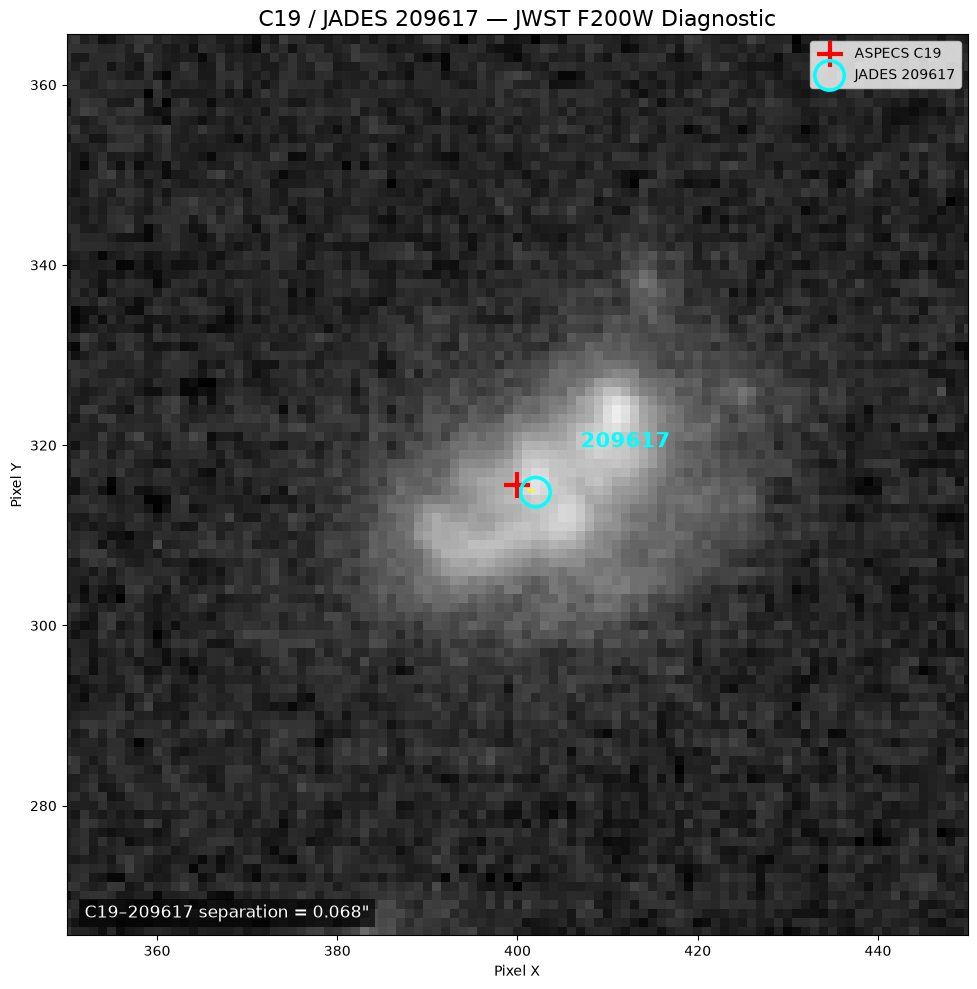

In [25]:
# ==========================================================
# Phase 5 — JWST Diagnostic Image
#
# C19 vs. JADES 209617
# ==========================================================

from astropy.coordinates import SkyCoord
from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch,
)

# ----------------------------------------------------------
# Correct C19 position
# ----------------------------------------------------------

c19_coord = SkyCoord(
    ra=53.15079167,
    dec=-27.77444444,
    unit="deg",
    frame="icrs",
)

# ----------------------------------------------------------
# JADES 209617 position
# ----------------------------------------------------------

jades_209617_coord = SkyCoord(
    ra=float(candidate_209617["RA"][0]),
    dec=float(candidate_209617["DEC"][0]),
    unit="deg",
    frame="icrs",
)

# ----------------------------------------------------------
# Convert sky coordinates to JWST image pixels
# ----------------------------------------------------------

c19_x, c19_y = large_cutout.wcs.world_to_pixel(c19_coord)

jades_x, jades_y = large_cutout.wcs.world_to_pixel(
    jades_209617_coord
)

# ----------------------------------------------------------
# Calculate the angular separation independently
# ----------------------------------------------------------

separation = c19_coord.separation(jades_209617_coord)

print("C19 / JADES 209617 diagnostic")
print("--------------------------------")
print(f"C19 pixel      : ({c19_x:.3f}, {c19_y:.3f})")
print(f"209617 pixel   : ({jades_x:.3f}, {jades_y:.3f})")
print(f"Separation     : {separation.arcsec:.4f} arcsec")

# ----------------------------------------------------------
# Normalize JWST F200W image
# ----------------------------------------------------------

norm = ImageNormalize(
    large_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

# ----------------------------------------------------------
# Create diagnostic figure
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# ----------------------------------------------------------
# C19 ALMA position
# ----------------------------------------------------------

ax.scatter(
    c19_x,
    c19_y,
    marker="+",
    s=350,
    color="red",
    linewidths=3,
    zorder=10,
    label="ASPECS C19",
)

# ----------------------------------------------------------
# JADES 209617 position
# ----------------------------------------------------------

ax.scatter(
    jades_x,
    jades_y,
    s=450,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2.5,
    zorder=11,
    label="JADES 209617",
)

ax.text(
    jades_x + 5,
    jades_y + 5,
    "209617",
    color="cyan",
    fontsize=15,
    weight="bold",
    zorder=12,
)

# ----------------------------------------------------------
# Draw a line between the two catalog positions
# ----------------------------------------------------------

ax.plot(
    [c19_x, jades_x],
    [c19_y, jades_y],
    color="yellow",
    linewidth=1.5,
    linestyle="--",
    zorder=9,
)

# ----------------------------------------------------------
# Zoom around C19
# ----------------------------------------------------------

half_width = 50

ax.set_xlim(
    c19_x - half_width,
    c19_x + half_width,
)

ax.set_ylim(
    c19_y - half_width,
    c19_y + half_width,
)

# ----------------------------------------------------------
# Figure cosmetics
# ----------------------------------------------------------

ax.set_title(
    "C19 / JADES 209617 — JWST F200W Diagnostic",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

ax.text(
    0.02,
    0.02,
    f"C19–209617 separation = {separation.arcsec:.3f}\"",
    transform=ax.transAxes,
    color="white",
    fontsize=12,
    bbox=dict(
        facecolor="black",
        alpha=0.65,
        edgecolor="none",
    ),
)

plt.tight_layout()
plt.show()

Midpoint: (400.980, 315.193)
Morphology cutout shape: (60, 60)


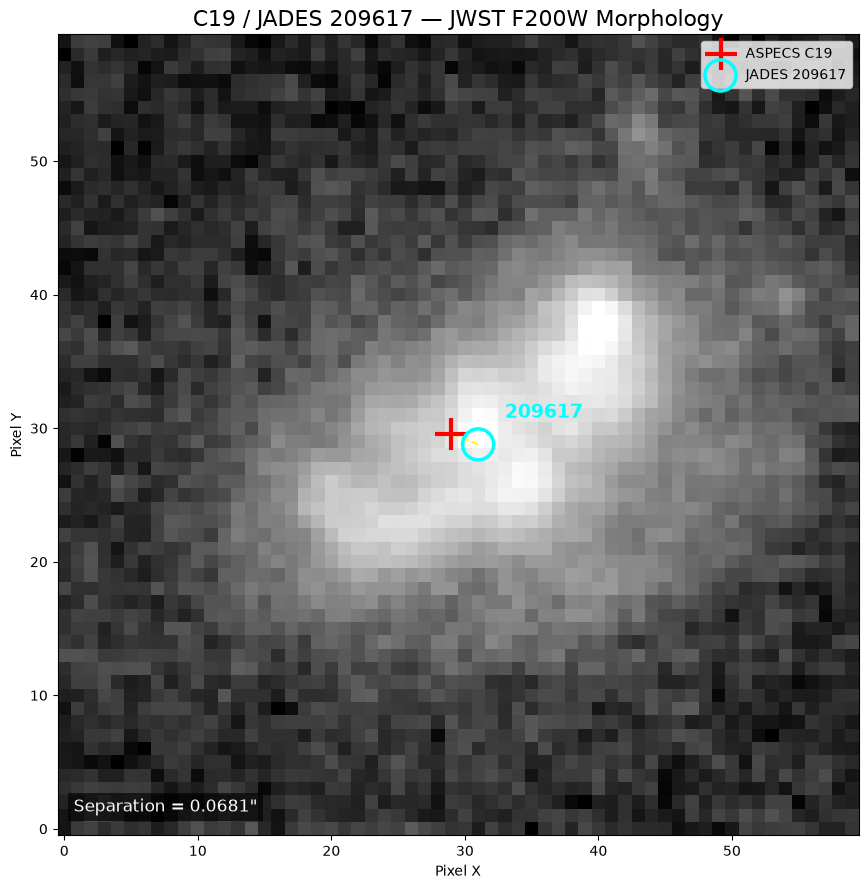

In [26]:
# ==========================================================
# Phase 4G
# C19 / JADES 209617 — JWST F200W Morphology Zoom
# ==========================================================

import matplotlib.pyplot as plt

from astropy.nddata import Cutout2D
from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch,
)

# ----------------------------------------------------------
# Midpoint between C19 and JADES 209617
# ----------------------------------------------------------

mid_x = (c19_cutout_x + jades_x) / 2
mid_y = (c19_cutout_y + jades_y) / 2

print(f"Midpoint: ({mid_x:.3f}, {mid_y:.3f})")

# ----------------------------------------------------------
# Create 60 × 60 pixel morphology cutout
# ----------------------------------------------------------

morphology_cutout = Cutout2D(
    data=large_cutout.data,
    position=(mid_x, mid_y),
    size=(60, 60),
    wcs=large_cutout.wcs,
)

print("Morphology cutout shape:", morphology_cutout.data.shape)

# ----------------------------------------------------------
# Normalize using AsinhStretch
# ----------------------------------------------------------

norm = ImageNormalize(
    morphology_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

# ----------------------------------------------------------
# Convert C19 and 209617 positions into cutout pixels
# ----------------------------------------------------------

origin_x, origin_y = morphology_cutout.origin_original

c19_x_small = c19_cutout_x - origin_x
c19_y_small = c19_cutout_y - origin_y

jades_x_small = jades_x - origin_x
jades_y_small = jades_y - origin_y

# ----------------------------------------------------------
# Display
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 9))

ax.imshow(
    morphology_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# ----------------------------------------------------------
# C19
# ----------------------------------------------------------

ax.scatter(
    c19_x_small,
    c19_y_small,
    marker="+",
    s=500,
    color="red",
    linewidths=3,
    zorder=10,
    label="ASPECS C19",
)

# ----------------------------------------------------------
# JADES 209617
# ----------------------------------------------------------

ax.scatter(
    jades_x_small,
    jades_y_small,
    marker="o",
    s=500,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2.5,
    zorder=11,
    label="JADES 209617",
)

ax.text(
    jades_x_small + 2,
    jades_y_small + 2,
    "209617",
    color="cyan",
    fontsize=14,
    weight="bold",
    zorder=12,
)

# ----------------------------------------------------------
# Connect the two positions
# ----------------------------------------------------------

ax.plot(
    [c19_x_small, jades_x_small],
    [c19_y_small, jades_y_small],
    color="yellow",
    linestyle="--",
    linewidth=1.5,
    zorder=9,
)

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

ax.set_title(
    "C19 / JADES 209617 — JWST F200W Morphology",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

# ----------------------------------------------------------
# Separation annotation
# ----------------------------------------------------------

ax.text(
    0.02,
    0.03,
    f"Separation = "
    f"{c19.separation(jades_209617_coord).arcsec:.4f}\"",
    transform=ax.transAxes,
    color="white",
    fontsize=12,
    bbox=dict(
        facecolor="black",
        alpha=0.65,
        edgecolor="none",
    ),
)

plt.tight_layout()
plt.show()

Extended morphology cutout: (120, 120)


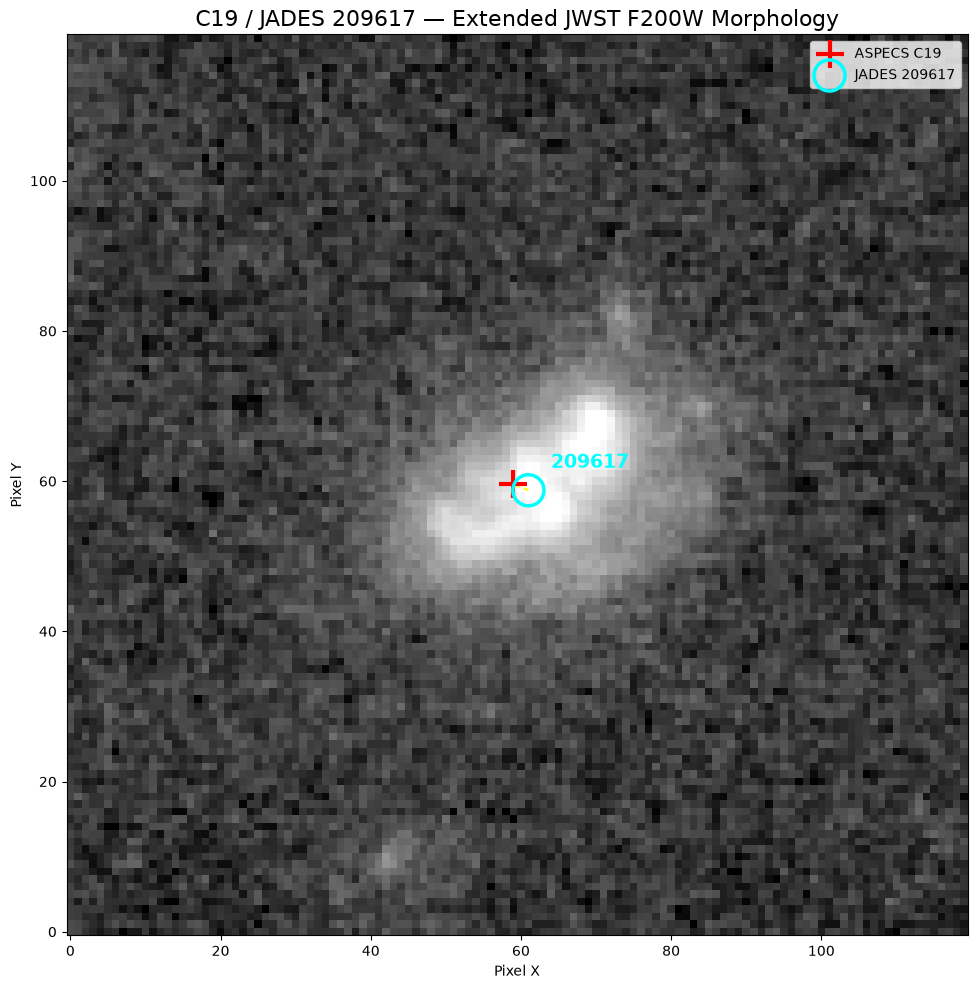

In [27]:
# ==========================================================
# Phase 4H-A
# C19 / JADES 209617 — Annotated Extended Morphology
# ==========================================================

# ----------------------------------------------------------
# Create 120 × 120 pixel cutout
# ----------------------------------------------------------

mid_x = (c19_cutout_x + jades_x) / 2
mid_y = (c19_cutout_y + jades_y) / 2

extended_cutout = Cutout2D(
    data=large_cutout.data,
    position=(mid_x, mid_y),
    size=(120, 120),
    wcs=large_cutout.wcs,
)

print("Extended morphology cutout:", extended_cutout.data.shape)

# ----------------------------------------------------------
# Normalize
# ----------------------------------------------------------

norm = ImageNormalize(
    extended_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

# ----------------------------------------------------------
# Convert positions into cutout pixels
# ----------------------------------------------------------

origin_x, origin_y = extended_cutout.origin_original

c19_x_ext = c19_cutout_x - origin_x
c19_y_ext = c19_cutout_y - origin_y

jades_x_ext = jades_x - origin_x
jades_y_ext = jades_y - origin_y

# ----------------------------------------------------------
# Display annotated image
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    extended_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# C19

ax.scatter(
    c19_x_ext,
    c19_y_ext,
    marker="+",
    s=400,
    color="red",
    linewidths=3,
    zorder=10,
    label="ASPECS C19",
)

# JADES 209617

ax.scatter(
    jades_x_ext,
    jades_y_ext,
    marker="o",
    s=500,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2.5,
    zorder=11,
    label="JADES 209617",
)

ax.text(
    jades_x_ext + 3,
    jades_y_ext + 3,
    "209617",
    color="cyan",
    fontsize=14,
    weight="bold",
)

# Connecting line

ax.plot(
    [c19_x_ext, jades_x_ext],
    [c19_y_ext, jades_y_ext],
    color="yellow",
    linestyle="--",
    linewidth=1.5,
    zorder=9,
)

ax.set_title(
    "C19 / JADES 209617 — Extended JWST F200W Morphology",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

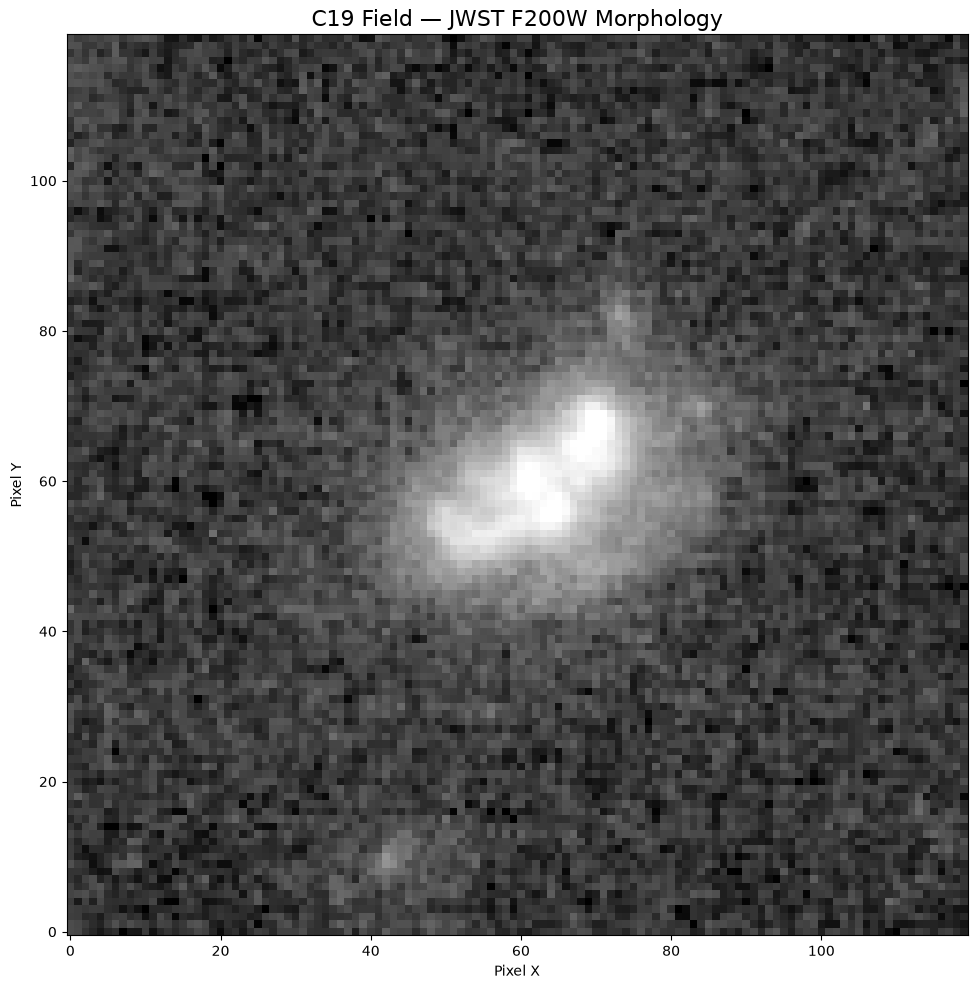

In [28]:
# ==========================================================
# Phase 4H-B
# C19 Field — Clean JWST F200W Morphology
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    extended_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

ax.set_title(
    "C19 Field — JWST F200W Morphology",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

plt.tight_layout()
plt.show()

JADES sources within 1 arcsec of C19:
-------------------------------------
  ID       RA       DEC     ...       z_peak         z_ml   separation_arcsec 
          deg       deg     ...                                               
------ --------- ---------- ... ----------------- --------- ------------------
209617 53.150772 -27.774437 ... 2.669999837875366 2.6699805 0.0681351052826673

Number of JADES sources within 1 arcsec: 1


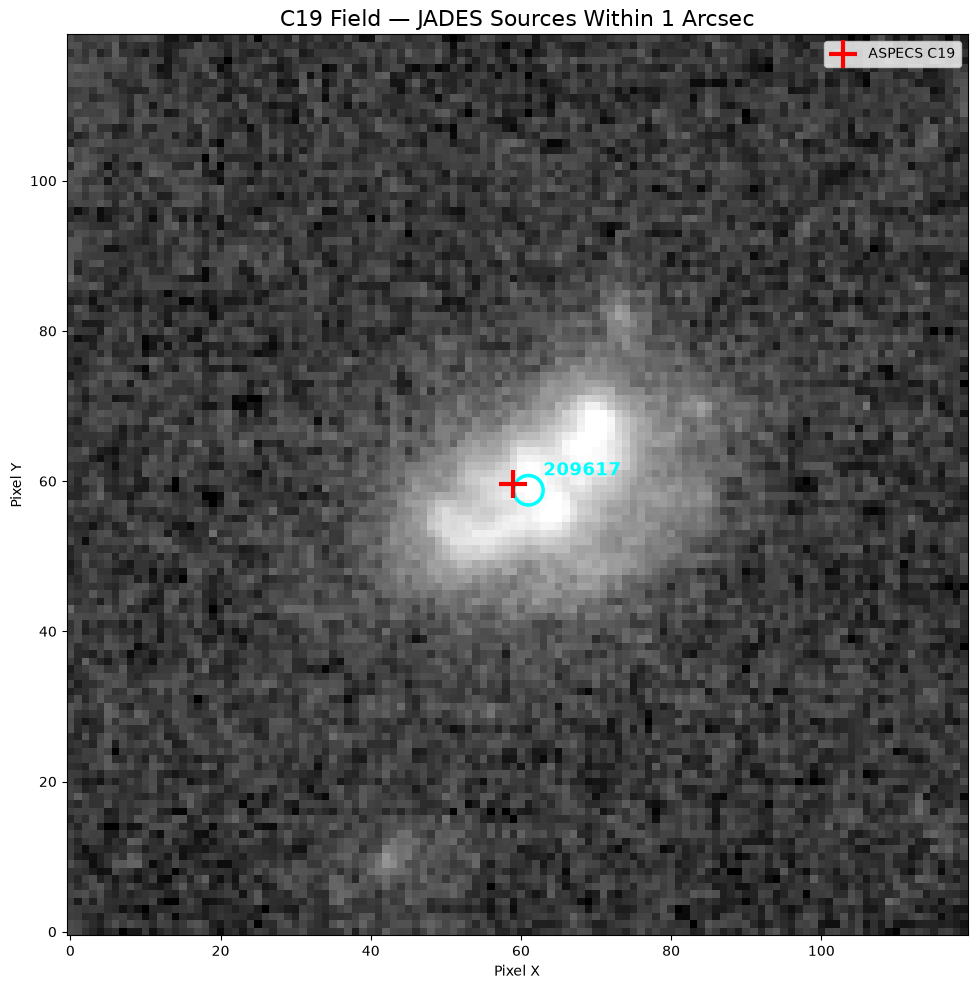

In [29]:
# ==========================================================
# Phase 4I
# All JADES Sources Within 1 Arcsec of C19
# ==========================================================

# ----------------------------------------------------------
# Select every JADES source within 1 arcsec
# ----------------------------------------------------------

near_1arcsec = neighbors[
    neighbors["separation_arcsec"] <= 1.0
]

print("JADES sources within 1 arcsec of C19:")
print("-------------------------------------")
print(
    near_1arcsec[
        [
            "ID",
            "RA",
            "DEC",
            "z_spec",
            "z_peak",
            "z_ml",
            "separation_arcsec",
        ]
    ]
)

print()
print(f"Number of JADES sources within 1 arcsec: {len(near_1arcsec)}")

# ==========================================================
# Phase 4I — Map JADES Sources Within 1 Arcsec of C19
# ==========================================================

# The RA and DEC columns already carry degree units.
# Do NOT multiply them by u.deg again.

near_coords = SkyCoord(
    ra=near_1arcsec["RA"],
    dec=near_1arcsec["DEC"],
    frame="icrs",
)

# Convert JADES sky positions to pixels in the 120 x 120 cutout
near_x, near_y = extended_cutout.wcs.world_to_pixel(
    near_coords
)

# ----------------------------------------------------------
# Display the 120 x 120 JWST morphology field
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    extended_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# ----------------------------------------------------------
# Plot every JADES source within 1 arcsec
# ----------------------------------------------------------

for row, xpix, ypix in zip(
    near_1arcsec,
    near_x,
    near_y,
):

    source_id = row["ID"]

    ax.scatter(
        xpix,
        ypix,
        s=450,
        facecolors="none",
        edgecolors="cyan",
        linewidths=2.5,
        zorder=10,
    )

    ax.text(
        xpix + 2,
        ypix + 2,
        str(source_id),
        color="cyan",
        fontsize=13,
        weight="bold",
        zorder=11,
    )

# ----------------------------------------------------------
# Mark C19
# ----------------------------------------------------------

ax.scatter(
    c19_x_ext,
    c19_y_ext,
    marker="+",
    s=400,
    color="red",
    linewidths=3,
    zorder=12,
    label="ASPECS C19",
)

# ----------------------------------------------------------
# Figure cosmetics
# ----------------------------------------------------------

ax.set_title(
    "C19 Field — JADES Sources Within 1 Arcsec",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [30]:
# ==========================================================
# Phase 4J
# F200W Intensity Peak
# ==========================================================

import numpy as np
from scipy.ndimage import gaussian_filter

# ----------------------------------------------------------
# Work with the 120 x 120 F200W cutout
# ----------------------------------------------------------

image = np.asarray(extended_cutout.data, dtype=float)

# Ignore invalid pixels
valid = np.isfinite(image)

# ----------------------------------------------------------
# Raw pixel intensity peak
# ----------------------------------------------------------

raw_image = np.where(valid, image, -np.inf)

raw_index = np.unravel_index(
    np.argmax(raw_image),
    raw_image.shape,
)

raw_y, raw_x = raw_index
raw_peak_value = image[raw_y, raw_x]

# ----------------------------------------------------------
# Smoothed image
# ----------------------------------------------------------

# A small Gaussian smoothing suppresses pixel-scale noise
# while preserving the overall galaxy morphology.

smoothed_image = gaussian_filter(
    np.nan_to_num(image, nan=0.0),
    sigma=2.0,
)

smooth_y, smooth_x = np.unravel_index(
    np.argmax(smoothed_image),
    smoothed_image.shape,
)

smooth_peak_value = smoothed_image[
    smooth_y,
    smooth_x,
]

# ----------------------------------------------------------
# Report results
# ----------------------------------------------------------

print("F200W INTENSITY PEAK")
print("====================")
print()
print("Raw pixel peak:")
print(f"  Pixel X = {raw_x:.3f}")
print(f"  Pixel Y = {raw_y:.3f}")
print(f"  Intensity = {raw_peak_value:.6g}")
print()
print("Smoothed morphology peak:")
print(f"  Pixel X = {smooth_x:.3f}")
print(f"  Pixel Y = {smooth_y:.3f}")
print(f"  Smoothed intensity = {smooth_peak_value:.6g}")

F200W INTENSITY PEAK

Raw pixel peak:
  Pixel X = 70.000
  Pixel Y = 68.000
  Intensity = 0.50965

Smoothed morphology peak:
  Pixel X = 62.000
  Pixel Y = 59.000
  Smoothed intensity = 0.380685


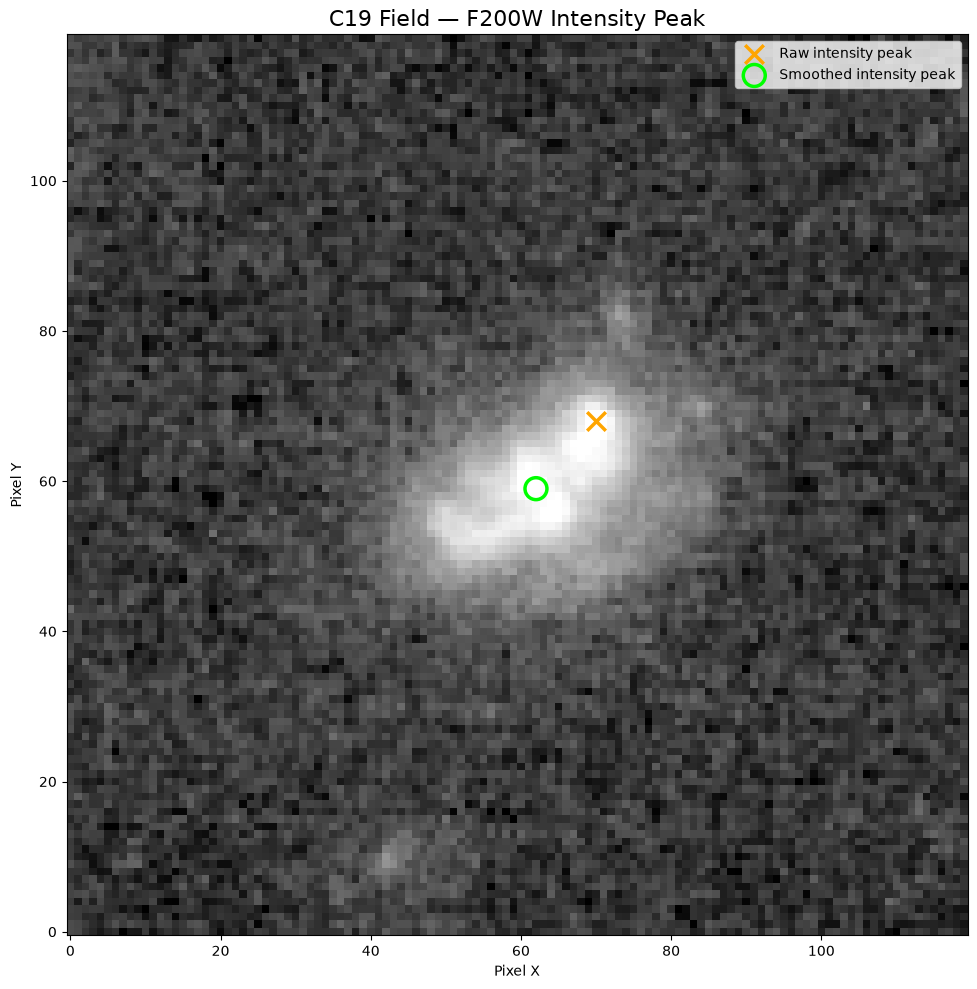

In [31]:
# ==========================================================
# Phase 4J — F200W Peak Diagnostic
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    extended_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# Raw pixel peak
ax.scatter(
    raw_x,
    raw_y,
    marker="x",
    s=180,
    color="orange",
    linewidths=2.5,
    label="Raw intensity peak",
)

# Smoothed morphology peak
ax.scatter(
    smooth_x,
    smooth_y,
    marker="o",
    s=250,
    facecolors="none",
    edgecolors="lime",
    linewidths=2.5,
    label="Smoothed intensity peak",
)

ax.set_title(
    "C19 Field — F200W Intensity Peak",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [32]:
# ==========================================================
# Phase 4K
# C19 / JADES 209617 / F200W Peak Offsets
# ==========================================================

import numpy as np
import astropy.units as u
from astropy.wcs.utils import proj_plane_pixel_scales

# ----------------------------------------------------------
# Positions
# ----------------------------------------------------------

positions = {
    "C19": (c19_x_ext, c19_y_ext),
    "JADES 209617": (jades_x_ext, jades_y_ext),
    "Raw F200W peak": (raw_x, raw_y),
    "Smoothed F200W peak": (smooth_x, smooth_y),
}

# ----------------------------------------------------------
# Pixel scale
# ----------------------------------------------------------

pixel_scale_arcsec = (
    proj_plane_pixel_scales(extended_cutout.wcs)[0]
    * u.deg
).to(u.arcsec).value

print(f"Pixel scale: {pixel_scale_arcsec:.4f} arcsec/pixel")
print()

# ----------------------------------------------------------
# Calculate separations from C19
# ----------------------------------------------------------

c19_position = np.array(positions["C19"])

print("Angular offsets from C19")
print("========================")

for name, position in positions.items():

    position = np.array(position)

    dx = position[0] - c19_position[0]
    dy = position[1] - c19_position[1]

    pixel_distance = np.sqrt(dx**2 + dy**2)

    angular_distance = (
        pixel_distance * pixel_scale_arcsec
    )

    print(f"{name}:")
    print(f"  dx = {dx:.3f} pixels")
    print(f"  dy = {dy:.3f} pixels")
    print(f"  separation = {pixel_distance:.3f} pixels")
    print(f"  angular separation = {angular_distance:.4f} arcsec")
    print()

Pixel scale: 0.0312 arcsec/pixel

Angular offsets from C19
C19:
  dx = 0.000 pixels
  dy = 0.000 pixels
  separation = 0.000 pixels
  angular separation = 0.0000 arcsec

JADES 209617:
  dx = 2.027 pixels
  dy = -0.808 pixels
  separation = 2.182 pixels
  angular separation = 0.0681 arcsec

Raw F200W peak:
  dx = 11.033 pixels
  dy = 8.403 pixels
  separation = 13.869 pixels
  angular separation = 0.4331 arcsec

Smoothed F200W peak:
  dx = 3.033 pixels
  dy = -0.597 pixels
  separation = 3.091 pixels
  angular separation = 0.0965 arcsec



In [33]:
# ==========================================================
# Phase 4L
# Quantitative F200W Morphology
# ==========================================================

import numpy as np

# ----------------------------------------------------------
# Image
# ----------------------------------------------------------

image = np.asarray(
    extended_cutout.data,
    dtype=float,
)

# ----------------------------------------------------------
# Define a morphology region around the smoothed peak
# ----------------------------------------------------------

yy, xx = np.indices(image.shape)

morph_radius = 30.0

region = (
    (xx - smooth_x)**2 +
    (yy - smooth_y)**2
) <= morph_radius**2

# ----------------------------------------------------------
# Estimate local background from the outer part of the region
# ----------------------------------------------------------

background_region = (
    ((xx - smooth_x)**2 + (yy - smooth_y)**2 >= 25**2)
    &
    ((xx - smooth_x)**2 + (yy - smooth_y)**2 <= 30**2)
    &
    np.isfinite(image)
)

background = np.median(
    image[background_region]
)

# Background-subtracted flux
flux = image - background

# Only positive flux contributes to the light moments
weights = np.where(
    region & np.isfinite(flux) & (flux > 0),
    flux,
    0.0,
)

total_flux = weights.sum()

# ----------------------------------------------------------
# Flux-weighted centroid
# ----------------------------------------------------------

centroid_x = np.sum(weights * xx) / total_flux
centroid_y = np.sum(weights * yy) / total_flux

# ----------------------------------------------------------
# Second central moments
# ----------------------------------------------------------

dx = xx - centroid_x
dy = yy - centroid_y

Mxx = np.sum(weights * dx**2) / total_flux
Myy = np.sum(weights * dy**2) / total_flux
Mxy = np.sum(weights * dx * dy) / total_flux

moment_matrix = np.array([
    [Mxx, Mxy],
    [Mxy, Myy],
])

# Eigenvalues/eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(
    moment_matrix
)

# Sort largest -> smallest
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

major_variance = eigenvalues[0]
minor_variance = eigenvalues[1]

major_sigma = np.sqrt(major_variance)
minor_sigma = np.sqrt(minor_variance)

# ----------------------------------------------------------
# Ellipticity
# ----------------------------------------------------------

axis_ratio = minor_sigma / major_sigma

ellipticity = 1.0 - axis_ratio

# ----------------------------------------------------------
# Major-axis position angle
#
# Measured in image coordinates:
# 0 degrees = +X direction
# positive toward +Y
# ----------------------------------------------------------

major_vector = eigenvectors[:, 0]

position_angle_deg = np.degrees(
    np.arctan2(
        major_vector[1],
        major_vector[0],
    )
)

# Normalize to -90 to +90 degrees
if position_angle_deg > 90:
    position_angle_deg -= 180

if position_angle_deg < -90:
    position_angle_deg += 180

# ----------------------------------------------------------
# Centroid offset from C19
# ----------------------------------------------------------

centroid_dx = centroid_x - c19_x_ext
centroid_dy = centroid_y - c19_y_ext

centroid_pixels = np.sqrt(
    centroid_dx**2 + centroid_dy**2
)

centroid_arcsec = (
    centroid_pixels * pixel_scale_arcsec
)

# ----------------------------------------------------------
# Report
# ----------------------------------------------------------

print("F200W QUANTITATIVE MORPHOLOGY")
print("============================")
print()
print(f"Background level       : {background:.6g}")
print(f"Total positive flux    : {total_flux:.6g}")
print()
print("Flux-weighted centroid:")
print(f"  X = {centroid_x:.3f}")
print(f"  Y = {centroid_y:.3f}")
print()
print("Second-moment structure:")
print(f"  Major sigma           : {major_sigma:.3f} pixels")
print(f"  Minor sigma           : {minor_sigma:.3f} pixels")
print(f"  Axis ratio (b/a)      : {axis_ratio:.3f}")
print(f"  Ellipticity           : {ellipticity:.3f}")
print(f"  Major-axis angle      : {position_angle_deg:.2f} deg")
print()
print("Centroid relative to C19:")
print(f"  dx                    : {centroid_dx:.3f} pixels")
print(f"  dy                    : {centroid_dy:.3f} pixels")
print(f"  Separation            : {centroid_pixels:.3f} pixels")
print(f"  Angular separation    : {centroid_arcsec:.4f} arcsec")

F200W QUANTITATIVE MORPHOLOGY

Background level       : 0.14846
Total positive flux    : 104.017

Flux-weighted centroid:
  X = 63.724
  Y = 59.394

Second-moment structure:
  Major sigma           : 10.601 pixels
  Minor sigma           : 7.421 pixels
  Axis ratio (b/a)      : 0.700
  Ellipticity           : 0.300
  Major-axis angle      : 31.82 deg

Centroid relative to C19:
  dx                    : 4.757 pixels
  dy                    : -0.203 pixels
  Separation            : 4.762 pixels
  Angular separation    : 0.1487 arcsec


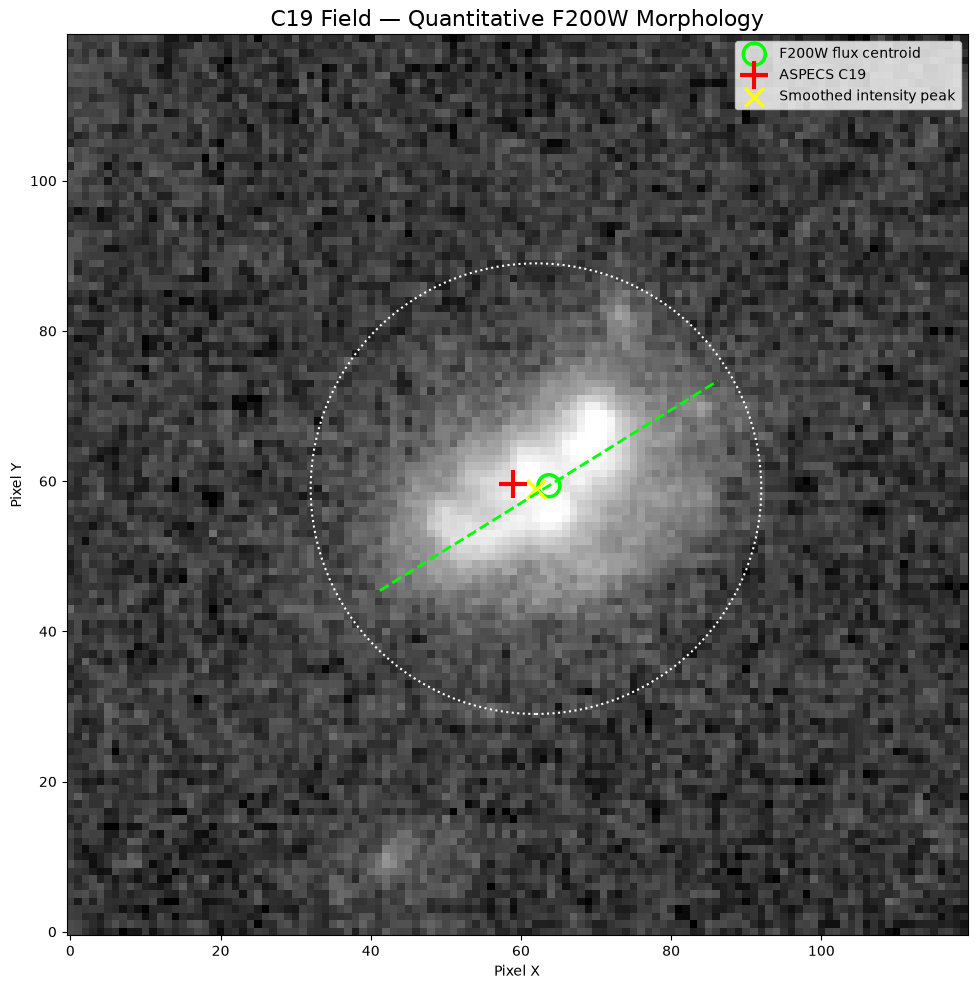

In [34]:
# ==========================================================
# Phase 4L — Morphology Diagnostic
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    extended_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# ----------------------------------------------------------
# Flux-weighted centroid
# ----------------------------------------------------------

ax.scatter(
    centroid_x,
    centroid_y,
    marker="o",
    s=250,
    facecolors="none",
    edgecolors="lime",
    linewidths=2.5,
    label="F200W flux centroid",
)

# ----------------------------------------------------------
# C19
# ----------------------------------------------------------

ax.scatter(
    c19_x_ext,
    c19_y_ext,
    marker="+",
    s=400,
    color="red",
    linewidths=3,
    label="ASPECS C19",
)

# ----------------------------------------------------------
# Smoothed intensity peak
# ----------------------------------------------------------

ax.scatter(
    smooth_x,
    smooth_y,
    marker="x",
    s=180,
    color="yellow",
    linewidths=2.5,
    label="Smoothed intensity peak",
)

# ----------------------------------------------------------
# Major axis
# ----------------------------------------------------------

theta = np.radians(position_angle_deg)

axis_length = major_sigma * 2.5

x1 = centroid_x - axis_length * np.cos(theta)
x2 = centroid_x + axis_length * np.cos(theta)

y1 = centroid_y - axis_length * np.sin(theta)
y2 = centroid_y + axis_length * np.sin(theta)

ax.plot(
    [x1, x2],
    [y1, y2],
    color="lime",
    linewidth=2,
    linestyle="--",
)

# ----------------------------------------------------------
# Morphology region
# ----------------------------------------------------------

circle = plt.Circle(
    (smooth_x, smooth_y),
    morph_radius,
    fill=False,
    linestyle=":",
    linewidth=1.5,
    edgecolor="white",
)

ax.add_patch(circle)

# ----------------------------------------------------------
# Cosmetics
# ----------------------------------------------------------

ax.set_title(
    "C19 Field — Quantitative F200W Morphology",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [35]:
# ==========================================================
# Phase 4L — Significant F200W Local Maxima
# ==========================================================

import numpy as np
from scipy.ndimage import maximum_filter

# ----------------------------------------------------------
# Find local maxima in the smoothed image
# ----------------------------------------------------------

# Require a peak to be the maximum within a 9 x 9 pixel
# neighborhood (~0.28 arcsec).

neighborhood = 9

local_max = (
    smoothed_image
    == maximum_filter(
        smoothed_image,
        size=neighborhood
    )
)

# ----------------------------------------------------------
# Apply a significance threshold
# ----------------------------------------------------------

# Estimate the background and noise from the outer region
# of the morphology field.

outer_region = (
    ((xx - smooth_x)**2 + (yy - smooth_y)**2 >= 25**2)
    &
    ((xx - smooth_x)**2 + (yy - smooth_y)**2 <= 30**2)
    &
    np.isfinite(smoothed_image)
)

background_smooth = np.median(
    smoothed_image[outer_region]
)

noise_smooth = np.std(
    smoothed_image[outer_region]
)

# Require peaks to be substantially above background.

threshold = (
    background_smooth + 3.0 * noise_smooth
)

peak_mask = (
    local_max
    & (smoothed_image >= threshold)
)

peak_y, peak_x = np.where(peak_mask)

# ----------------------------------------------------------
# Sort peaks by brightness
# ----------------------------------------------------------

peak_values = smoothed_image[peak_y, peak_x]

order = np.argsort(peak_values)[::-1]

peak_x = peak_x[order]
peak_y = peak_y[order]
peak_values = peak_values[order]

# ----------------------------------------------------------
# Print results
# ----------------------------------------------------------

print("SIGNIFICANT F200W LOCAL MAXIMA")
print("==============================")
print()
print(f"Background = {background_smooth:.6g}")
print(f"Noise      = {noise_smooth:.6g}")
print(f"Threshold  = {threshold:.6g}")
print()
print(f"Number of detected peaks: {len(peak_x)}")
print()

for i, (x_peak, y_peak, value) in enumerate(
    zip(peak_x, peak_y, peak_values),
    start=1,
):
    dx = x_peak - c19_x_ext
    dy = y_peak - c19_y_ext

    separation_pixels = np.sqrt(
        dx**2 + dy**2
    )

    separation_arcsec = (
        separation_pixels
        * pixel_scale_arcsec
    )

    print(
        f"{i:2d}. "
        f"X={x_peak:6.1f}  "
        f"Y={y_peak:6.1f}  "
        f"intensity={value:.6f}  "
        f"sep_C19={separation_arcsec:.4f}\""
    )

SIGNIFICANT F200W LOCAL MAXIMA

Background = 0.148668
Noise      = 0.00609861
Threshold  = 0.166964

Number of detected peaks: 3

 1. X=  62.0  Y=  59.0  intensity=0.380685  sep_C19=0.0965"
 2. X=  69.0  Y=  66.0  intensity=0.380511  sep_C19=0.3717"
 3. X=  73.0  Y=  81.0  intensity=0.175553  sep_C19=0.7992"


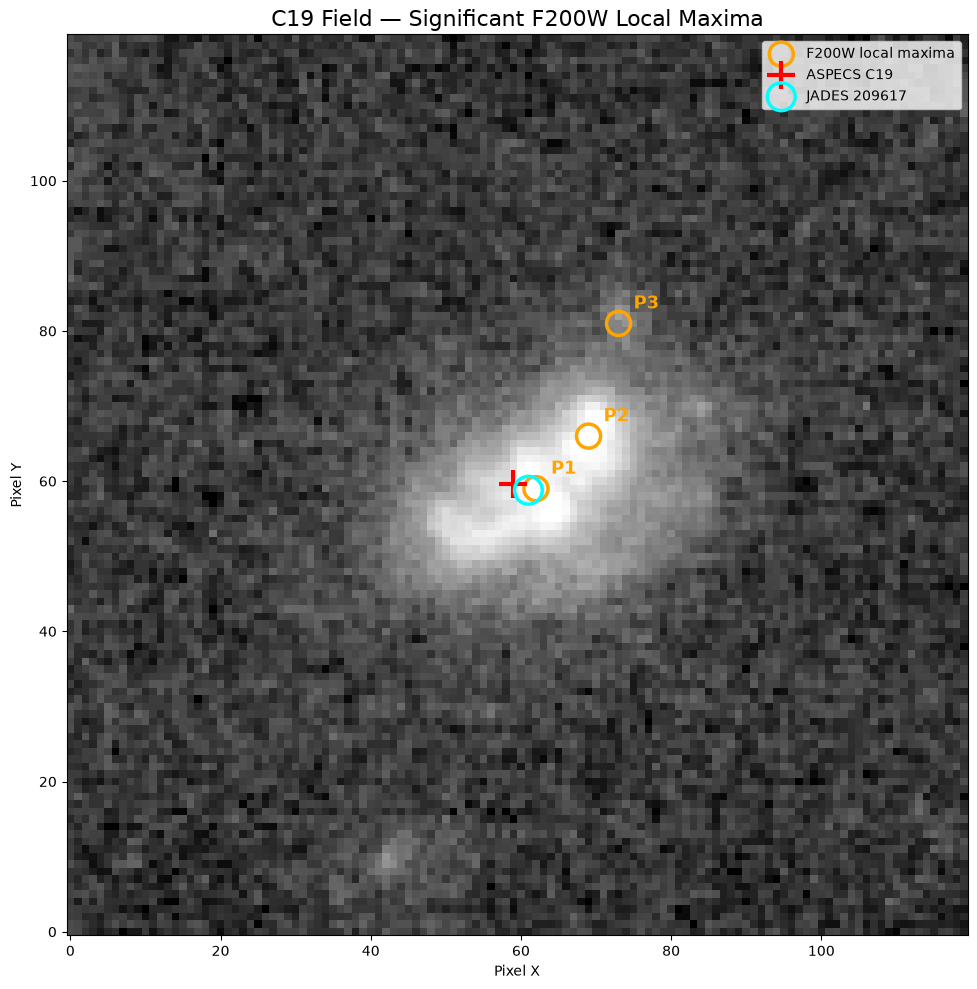

In [36]:
# ==========================================================
# Phase 4L — Local Maxima Diagnostic
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    extended_cutout.data,
    origin="lower",
    cmap="gray",
    norm=norm,
)

# Plot detected maxima

ax.scatter(
    peak_x,
    peak_y,
    marker="o",
    s=300,
    facecolors="none",
    edgecolors="orange",
    linewidths=2.5,
    label="F200W local maxima",
)

# Label peaks

for i, (x_peak, y_peak) in enumerate(
    zip(peak_x, peak_y),
    start=1,
):
    ax.text(
        x_peak + 2,
        y_peak + 2,
        f"P{i}",
        color="orange",
        fontsize=13,
        weight="bold",
    )

# C19

ax.scatter(
    c19_x_ext,
    c19_y_ext,
    marker="+",
    s=400,
    color="red",
    linewidths=3,
    label="ASPECS C19",
)

# JADES 209617

ax.scatter(
    jades_x_ext,
    jades_y_ext,
    marker="o",
    s=400,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2.5,
    label="JADES 209617",
)

ax.set_title(
    "C19 Field — Significant F200W Local Maxima",
    fontsize=16,
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [37]:
# ==========================================================
# Phase 4M — P2 JADES Catalog Test
# ==========================================================

from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# ----------------------------------------------------------
# P2 position in the extended JWST cutout
# ----------------------------------------------------------

p2_x = 69.0
p2_y = 66.0

p2_coord = extended_cutout.wcs.pixel_to_world(
    p2_x,
    p2_y
)

print("P2 sky position")
print("================")
print(f"RA  = {p2_coord.ra.deg:.8f} deg")
print(f"DEC = {p2_coord.dec.deg:.8f} deg")
print()

# ----------------------------------------------------------
# Compare P2 against every JADES source
# ----------------------------------------------------------

p2_separations = p2_coord.separation(jades_coords)

# Sort by angular separation

order = np.argsort(p2_separations)

# Show nearest 10

print("Nearest JADES sources to P2")
print("===========================")

for rank, idx in enumerate(order[:10], start=1):

    row = jades_core[idx]

    print(
        f"{rank:2d}. "
        f"ID={row['ID']}  "
        f"separation={p2_separations[idx].arcsec:.4f}\"  "
        f"z_peak={row['z_peak']:.3f}  "
        f"z_ml={row['z_ml']:.3f}"
    )

P2 sky position
RA  = 53.15076626 deg
DEC = -27.77434368 deg

Nearest JADES sources to P2
 1. ID=209617  separation=0.3365"  z_peak=2.670  z_ml=2.670
 2. ID=399845  separation=1.5646"  z_peak=10.960  z_ml=10.948
 3. ID=209615  separation=1.9430"  z_peak=2.280  z_ml=2.282
 4. ID=130747  separation=1.9599"  z_peak=1.700  z_ml=1.697
 5. ID=130286  separation=1.9676"  z_peak=0.460  z_ml=0.463
 6. ID=130129  separation=2.0015"  z_peak=0.520  z_ml=0.516
 7. ID=277367  separation=2.3263"  z_peak=9.580  z_ml=9.575
 8. ID=130673  separation=2.5420"  z_peak=1.790  z_ml=1.761
 9. ID=265785  separation=2.5702"  z_peak=0.220  z_ml=0.223
10. ID=130192  separation=2.6929"  z_peak=4.370  z_ml=4.366


In [38]:
# ==========================================================
# Phase 4M — P2 JADES Source Counts
# ==========================================================

radii = [0.10, 0.20, 0.30, 0.40, 0.50, 1.00]

print("JADES sources around P2")
print("=======================")

for radius in radii:

    mask = p2_separations <= radius * u.arcsec

    print(
        f"Within {radius:4.2f}\" : "
        f"{mask.sum()} source(s)"
    )

JADES sources around P2
Within 0.10" : 0 source(s)
Within 0.20" : 0 source(s)
Within 0.30" : 0 source(s)
Within 0.40" : 1 source(s)
Within 0.50" : 1 source(s)
Within 1.00" : 1 source(s)


In [39]:
# ==========================================================
# Phase 4M — Nearest JADES Source to P2
# ==========================================================

nearest_idx = order[0]

p2_nearest = jades_core[nearest_idx]

print("Nearest JADES source to P2")
print("==========================")
print(f"ID          : {p2_nearest['ID']}")
print(f"RA          : {p2_nearest['RA']}")
print(f"DEC         : {p2_nearest['DEC']}")
print(f"z_spec      : {p2_nearest['z_spec']}")
print(f"z_peak      : {p2_nearest['z_peak']}")
print(f"z_ml        : {p2_nearest['z_ml']}")
print(
    f"Separation  : "
    f"{p2_separations[nearest_idx].arcsec:.4f}\""
)

Nearest JADES source to P2
ID          : 209617
RA          : 53.150772
DEC         : -27.774437
z_spec      : -9999.0
z_peak      : 2.669999837875366
z_ml        : 2.669980525970459
Separation  : 0.3365"


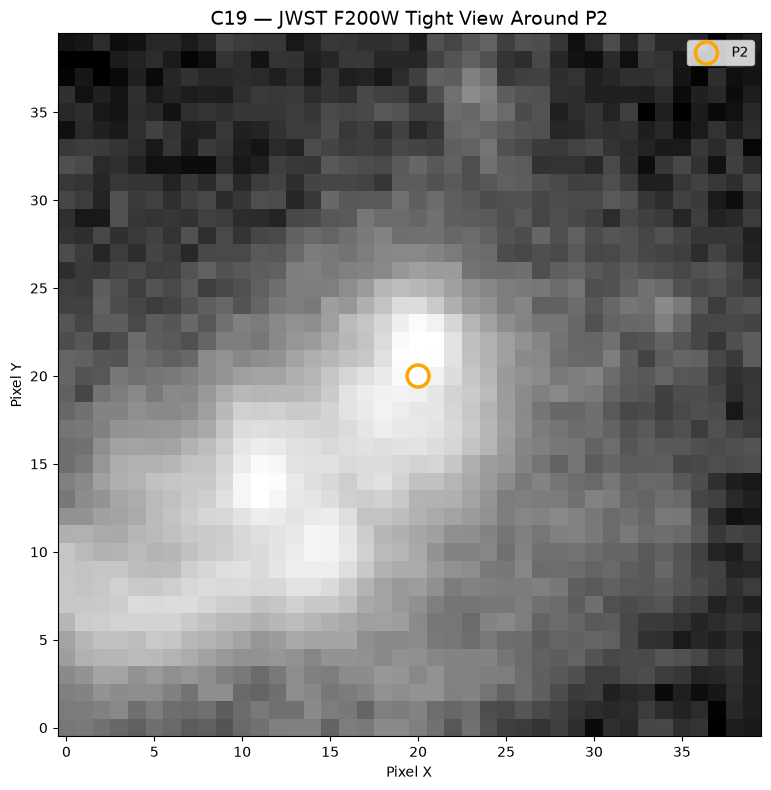

In [40]:
# ==========================================================
# Phase 4N — JWST F200W Cutout Around P2
# ==========================================================

p2_size = (40, 40)

p2_cutout = Cutout2D(
    data=jwst_image,
    position=p2_coord,
    size=p2_size,
    wcs=jwst_wcs
)

# ----------------------------------------------------------
# Display
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

p2_norm = ImageNormalize(
    p2_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch()
)

ax.imshow(
    p2_cutout.data,
    origin="lower",
    cmap="gray",
    norm=p2_norm
)

# P2 is at the center of this cutout

cx = p2_cutout.data.shape[1] / 2
cy = p2_cutout.data.shape[0] / 2

ax.scatter(
    cx,
    cy,
    marker="o",
    s=250,
    facecolors="none",
    edgecolors="orange",
    linewidths=2.5,
    label="P2"
)

ax.set_title(
    "C19 — JWST F200W Tight View Around P2",
    fontsize=14
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend()

plt.tight_layout()
plt.show()

In [41]:
# ==========================================================
# Phase 4P — JADES 209617 SED / Redshift Association Test
# Step 1: Inspect the catalog record
# ==========================================================

target_id = 209617

# Find the JADES table already loaded in the notebook.
# We look through common variable names first.

possible_tables = [
    "jades_catalog",
    "jades",
    "jades_table",
    "jades_catalog_table",
    "jades_dr5",
]

jades_table = None
jades_name = None

for name in possible_tables:
    if name in globals():
        obj = globals()[name]

        if hasattr(obj, "colnames"):
            if "ID" in obj.colnames or "id" in obj.colnames:
                jades_table = obj
                jades_name = name
                break

if jades_table is None:
    raise NameError(
        "Could not find the JADES catalog table. "
        "Please tell me the variable name used for the JADES catalog."
    )

print(f"Using JADES table: {jades_name}")
print()

# Determine the ID column
id_column = "ID" if "ID" in jades_table.colnames else "id"

# Select JADES 209617
row = jades_table[jades_table[id_column] == target_id]

print("JADES 209617 record:")
print(row)

print()
print("Number of matching records:", len(row))

print()
print("Catalog columns:")
print(jades_table.colnames)

Using JADES table: jades

JADES 209617 record:
  ID       RA       DEC     ...   z_chisq_z_lt_4     z_bins    Prob_z_bins
          deg       deg     ...                                           
------ --------- ---------- ... ----------------- ------------ -----------
209617 53.150772 -27.774437 ... 2.669999837875366 0.35 .. 21.0  0.0 .. 0.0

Number of matching records: 1

Catalog columns:
['ID', 'RA', 'DEC', 'A_KRON', 'B_KRON', 'THETA_KRON', 'F070W_KRON', 'F070W_KRON_e', 'F070W_KRON_ei', 'F070W_KRON_bkg', 'A_KRON_S', 'B_KRON_S', 'THETA_KRON_S', 'F070W_KRON_S', 'F070W_KRON_S_e', 'F070W_KRON_S_ei', 'F070W_KRON_S_bkg', 'F090W_KRON', 'F090W_KRON_e', 'F090W_KRON_ei', 'F090W_KRON_bkg', 'F090W_KRON_S', 'F090W_KRON_S_e', 'F090W_KRON_S_ei', 'F090W_KRON_S_bkg', 'F105W_KRON', 'F105W_KRON_e', 'F105W_KRON_ei', 'F105W_KRON_bkg', 'F105W_KRON_S', 'F105W_KRON_S_e', 'F105W_KRON_S_ei', 'F105W_KRON_S_bkg', 'F115W_KRON', 'F115W_KRON_e', 'F115W_KRON_ei', 'F115W_KRON_bkg', 'F115W_KRON_S', 'F115W_KRON_S_e

In [42]:
# ==========================================================
# Phase 4P — Step 2
# JADES 209617 redshift diagnostics
# ==========================================================

row = jades[jades["ID"] == 209617][0]

redshift_columns = [
    "z_spec",
    "z_a",
    "z_ml",
    "z_peak",
    "chi_a",
    "chi_peak",
    "l68",
    "u68",
    "l95",
    "u95",
    "l99",
    "u99",
    "z025",
    "z160",
    "z500",
    "z840",
    "z975",
    "Prob_gt_5",
    "Prob_gt_6",
    "Prob_gt_7",
    "Prob_gt_8",
    "Prob_gt_9",
    "z_chisq_z_lt_4",
]

print("JADES 209617 — Redshift Diagnostics")
print("=" * 55)

for col in redshift_columns:
    print(f"{col:18s} = {row[col]}")

JADES 209617 — Redshift Diagnostics
z_spec             = -9999.0
z_a                = 2.669999837875366
z_ml               = 2.669980525970459
z_peak             = 2.669999837875366
chi_a              = 24.019433975219727
chi_peak           = 24.019433975219727
l68                = 2.5831884748180536
u68                = 2.79274892375287
l95                = 2.5015874027472016
u95                = 2.9411412070323313
l99                = 2.4402175837527826
u99                = 3.040037410516664
z025               = 2.5070478916168213
z160               = 2.5863003730773926
z500               = 2.684140682220459
z840               = 2.7945632934570312
z975               = 2.933375358581543
Prob_gt_5          = 0.0
Prob_gt_6          = 0.0
Prob_gt_7          = 0.0
Prob_gt_8          = 0.0
Prob_gt_9          = 0.0
z_chisq_z_lt_4     = 2.669999837875366


In [43]:
# ==========================================================
# Phase 4P — Step 3
# Inspect the JADES redshift probability distribution
# ==========================================================

z_bins = np.array(row["z_bins"], dtype=float)
prob_bins = np.array(row["Prob_z_bins"], dtype=float)

print("Number of redshift bins:", len(z_bins))
print()

print("First 20 redshift bins:")
print(z_bins[:20])

print()
print("First 20 probability values:")
print(prob_bins[:20])

print()
print("Probability sum:", np.sum(prob_bins))

# ----------------------------------------------------------
# Find the bin closest to the C19 CO redshift
# ----------------------------------------------------------

c19_z = 2.574

nearest_bin = np.argmin(
    np.abs(z_bins - c19_z)
)

print()
print("C19 redshift:", c19_z)
print(
    "Nearest JADES PDF bin:",
    z_bins[nearest_bin]
)
print(
    "Probability in that bin:",
    prob_bins[nearest_bin]
)

Number of redshift bins: 22

First 20 redshift bins:
[ 0.35  1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   11.
 12.   13.   14.   15.   16.   17.   18.   19.  ]

First 20 probability values:
[0.00000000e+00 3.56867806e-32 1.44182029e-02 9.80736793e-01
 2.74360585e-09 3.64100873e-31 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Probability sum: 0.995154998287214

C19 redshift: 2.574
Nearest JADES PDF bin: 3.0
Probability in that bin: 0.9807367926034231


In [44]:
# ==========================================================
# Phase 4P — Step 4
# Inspect JADES z_bins metadata
# ==========================================================

print("z_bins metadata")
print("================")

print(jades["z_bins"].description)

print()
print("Prob_z_bins metadata")
print("====================")

print(jades["Prob_z_bins"].description)

z_bins metadata
None

Prob_z_bins metadata
None


In [45]:
# ==========================================================
# Phase 4Q
# P1 vs P2 Multi-band JWST Color Test
#
# Step 1 — Inventory available JWST images
# ==========================================================

from pathlib import Path

jwst_data = Path(
    "/home/glenn/Projects/CosmicIntelligenceLab/data"
) / "raw" / "jwst"

print("JWST data directory:")
print(jwst_data)
print()

jwst_files = sorted(
    list(jwst_data.rglob("*.fits")) +
    list(jwst_data.rglob("*.fits.gz"))
)

print(f"JWST FITS files found: {len(jwst_files)}")
print()

for f in jwst_files:
    print(f)

JWST data directory:
/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst

JWST FITS files found: 3

/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/JWST/jw01180-o013_t011_nircam_clear-f200w/jw01180-o013_t011_nircam_clear-f200w_i2d.fits
/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/jw06541-o005_t005_nircam_clear-f200w_i2d.fits
/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/mastDownload/JWST/jw06541-o005_t005_nircam_clear-f200w/jw06541-o005_t005_nircam_clear-f200w_i2d.fits


In [46]:
# ==========================================================
# Phase 4Q — P1 / P2 Reference Positions
# ==========================================================

p1_x = 62.0
p1_y = 59.0

p2_x = 69.0
p2_y = 66.0

print("P1:")
print(f"  X = {p1_x:.1f}")
print(f"  Y = {p1_y:.1f}")
print()

print("P2:")
print(f"  X = {p2_x:.1f}")
print(f"  Y = {p2_y:.1f}")
print()

print("P1–P2 separation:")
p1_p2_pixels = np.sqrt(
    (p2_x - p1_x)**2 +
    (p2_y - p1_y)**2
)

print(f"  {p1_p2_pixels:.3f} pixels")
print(
    f"  {p1_p2_pixels * pixel_scale_arcsec:.4f} arcsec"
)

P1:
  X = 62.0
  Y = 59.0

P2:
  X = 69.0
  Y = 66.0

P1–P2 separation:
  9.899 pixels
  0.3091 arcsec


In [47]:
# ==========================================================
# Phase 4Q — F200W Repeatability Test
# Step 2 — Compare the two independent JWST observations
# ==========================================================

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
import numpy as np

# ----------------------------------------------------------
# JWST F200W files
# ----------------------------------------------------------

jwst_file_1 = (
    "/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/"
    "JWST/jw01180-o013_t011_nircam_clear-f200w/"
    "jw01180-o013_t011_nircam_clear-f200w_i2d.fits"
)

jwst_file_2 = (
    "/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/"
    "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

# ----------------------------------------------------------
# Open both observations
# ----------------------------------------------------------

hdul_1 = fits.open(jwst_file_1)
hdul_2 = fits.open(jwst_file_2)

print("Observation 1:")
hdul_1.info()

print()
print("Observation 2:")
hdul_2.info()

# ----------------------------------------------------------
# Extract SCI data and WCS
# ----------------------------------------------------------

jwst_image_1 = hdul_1["SCI"].data
jwst_wcs_1 = WCS(hdul_1["SCI"].header)

jwst_image_2 = hdul_2["SCI"].data
jwst_wcs_2 = WCS(hdul_2["SCI"].header)

# ----------------------------------------------------------
# C19 sky position
# ----------------------------------------------------------

c19_coord = SkyCoord(
    ra=53.150772 * u.deg,
    dec=-27.774437 * u.deg,
    frame="icrs",
)

# ----------------------------------------------------------
# Convert C19 to pixels in each observation
# ----------------------------------------------------------

c19_pixel_1 = jwst_wcs_1.world_to_pixel(c19_coord)
c19_pixel_2 = jwst_wcs_2.world_to_pixel(c19_coord)

# ----------------------------------------------------------
# Pixel scales
# ----------------------------------------------------------

scale_1 = (
    proj_plane_pixel_scales(jwst_wcs_1)[0]
    * u.deg
).to(u.arcsec).value

scale_2 = (
    proj_plane_pixel_scales(jwst_wcs_2)[0]
    * u.deg
).to(u.arcsec).value

# ----------------------------------------------------------
# Report
# ----------------------------------------------------------

print()
print("=" * 60)
print("F200W OBSERVATION COMPARISON")
print("=" * 60)

print()
print("JWST observation 1 — jw01180")
print(f"Image shape       : {jwst_image_1.shape}")
print(f"Pixel scale       : {scale_1:.5f} arcsec/pixel")
print(
    f"C19 pixel position: "
    f"({c19_pixel_1[0]:.3f}, {c19_pixel_1[1]:.3f})"
)

print()
print("JWST observation 2 — jw06541")
print(f"Image shape       : {jwst_image_2.shape}")
print(f"Pixel scale       : {scale_2:.5f} arcsec/pixel")
print(
    f"C19 pixel position: "
    f"({c19_pixel_2[0]:.3f}, {c19_pixel_2[1]:.3f})"
)

Observation 1:
Filename: /home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/JWST/jw01180-o013_t011_nircam_clear-f200w/jw01180-o013_t011_nircam_clear-f200w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     283   ()      
  1  SCI           1 ImageHDU        75   (10009, 4512)   float32   
  2  ERR           1 ImageHDU        10   (10009, 4512)   float32   
  3  CON           1 ImageHDU        10   (10009, 4512, 3)   int32   
  4  WHT           1 ImageHDU         9   (10009, 4512)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (10009, 4512)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (10009, 4512)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (10009, 4512)   float32   
  8  HDRTAB        1 BinTableHDU    542   72R x 266C   [23A, 5A, 3A, 45A, 7A, 13A, 3A, 5A, 5A, 7A, 10A, 4A, L, D, D, 32A, 50A, 62A, 21A, 3A, 20A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 22A, 2A, 26A, 20A, 2

Set DATE-AVG to '2023-10-03T19:48:07.188' from MJD-AVG.
Set DATE-END to '2023-10-03T21:37:33.999' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.589899 from OBSGEO-[XYZ].
Set OBSGEO-H to 1231318776.096 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-01-01T09:29:55.361' from MJD-AVG.
Set DATE-END to '2024-01-01T09:56:08.363' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.851392 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694081725.647 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


P1 sky position:
RA=53.15076647  DEC=-27.77442955

P2 sky position:
RA=53.15076626  DEC=-27.77434368

JW01180 pixel positions:
P1 = (3637.218, 1832.544)
P2 = (3628.483, 1837.200)

JW06541 pixel positions:
P1 = (3879.000, 315.000)
P2 = (3886.000, 322.000)


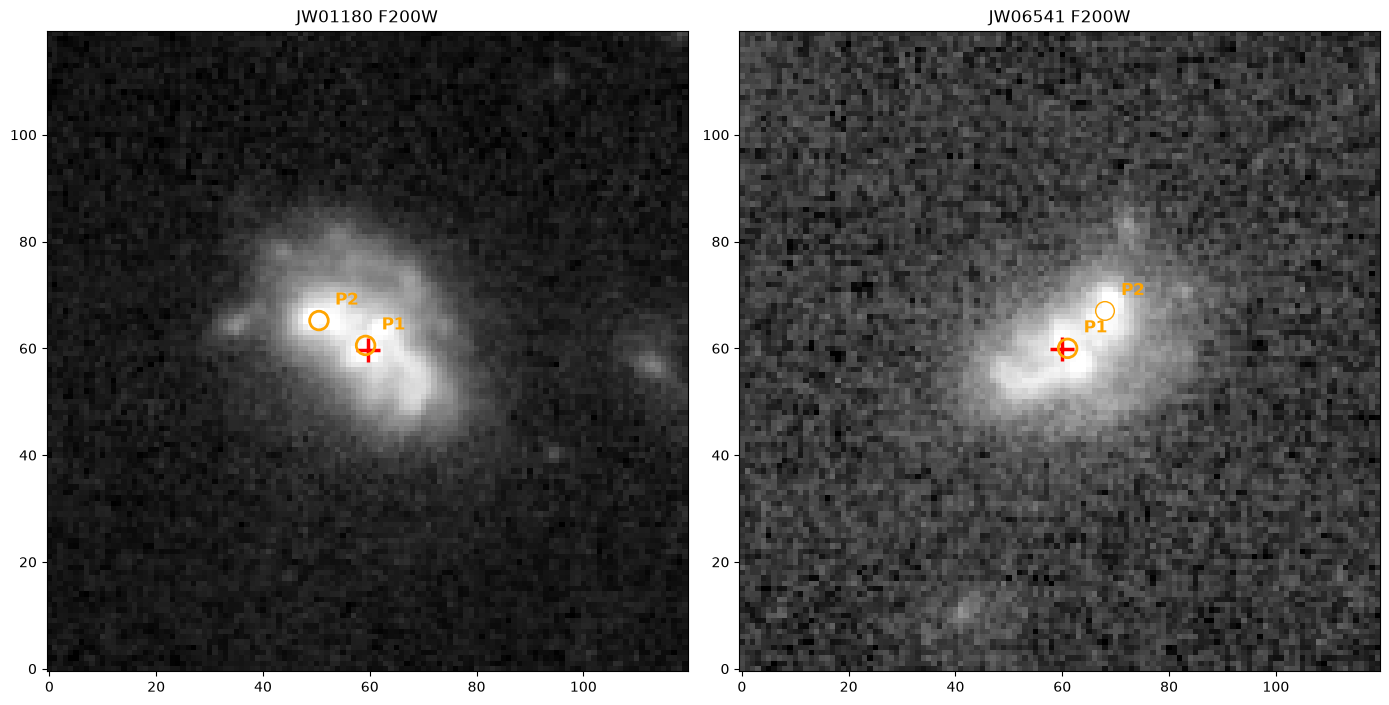

In [48]:
# ==========================================================
# Phase 4Q — Step 3
# P1 / P2 Repeatability in Independent F200W Observations
# ==========================================================

from astropy.nddata import Cutout2D
import matplotlib.pyplot as plt
from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch,
)

# ----------------------------------------------------------
# P1 and P2 sky coordinates
# ----------------------------------------------------------

p1_coord = extended_cutout.wcs.pixel_to_world(
    p1_x,
    p1_y
)

p2_coord = extended_cutout.wcs.pixel_to_world(
    p2_x,
    p2_y
)

print("P1 sky position:")
print(
    f"RA={p1_coord.ra.deg:.8f}  "
    f"DEC={p1_coord.dec.deg:.8f}"
)

print()
print("P2 sky position:")
print(
    f"RA={p2_coord.ra.deg:.8f}  "
    f"DEC={p2_coord.dec.deg:.8f}"
)

# ----------------------------------------------------------
# Convert P1/P2 into each JWST observation
# ----------------------------------------------------------

p1_pix_1 = jwst_wcs_1.world_to_pixel(p1_coord)
p2_pix_1 = jwst_wcs_1.world_to_pixel(p2_coord)

p1_pix_2 = jwst_wcs_2.world_to_pixel(p1_coord)
p2_pix_2 = jwst_wcs_2.world_to_pixel(p2_coord)

print()
print("JW01180 pixel positions:")
print(f"P1 = ({p1_pix_1[0]:.3f}, {p1_pix_1[1]:.3f})")
print(f"P2 = ({p2_pix_1[0]:.3f}, {p2_pix_1[1]:.3f})")

print()
print("JW06541 pixel positions:")
print(f"P1 = ({p1_pix_2[0]:.3f}, {p1_pix_2[1]:.3f})")
print(f"P2 = ({p2_pix_2[0]:.3f}, {p2_pix_2[1]:.3f})")

# ----------------------------------------------------------
# Create matched 120 x 120 cutouts centered on C19
# ----------------------------------------------------------

repeat_cutout_1 = Cutout2D(
    data=jwst_image_1,
    position=c19_coord,
    size=(120, 120),
    wcs=jwst_wcs_1,
)

repeat_cutout_2 = Cutout2D(
    data=jwst_image_2,
    position=c19_coord,
    size=(120, 120),
    wcs=jwst_wcs_2,
)

# ----------------------------------------------------------
# Convert P1/P2 into cutout pixel coordinates
# ----------------------------------------------------------

p1_cut_1 = repeat_cutout_1.wcs.world_to_pixel(p1_coord)
p2_cut_1 = repeat_cutout_1.wcs.world_to_pixel(p2_coord)

p1_cut_2 = repeat_cutout_2.wcs.world_to_pixel(p1_coord)
p2_cut_2 = repeat_cutout_2.wcs.world_to_pixel(p2_coord)

c19_cut_1 = repeat_cutout_1.wcs.world_to_pixel(c19_coord)
c19_cut_2 = repeat_cutout_2.wcs.world_to_pixel(c19_coord)

# ----------------------------------------------------------
# Normalize each image independently
# ----------------------------------------------------------

norm_1 = ImageNormalize(
    repeat_cutout_1.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

norm_2 = ImageNormalize(
    repeat_cutout_2.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch(),
)

# ----------------------------------------------------------
# Plot side-by-side
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7),
)

# ----------------------------------------------------------
# JW01180
# ----------------------------------------------------------

ax = axes[0]

ax.imshow(
    repeat_cutout_1.data,
    origin="lower",
    cmap="gray",
    norm=norm_1,
)

ax.scatter(
    c19_cut_1[0],
    c19_cut_1[1],
    marker="+",
    s=300,
    color="red",
    linewidths=2.5,
    label="C19",
)

ax.scatter(
    p1_cut_1[0],
    p1_cut_1[1],
    marker="o",
    s=180,
    facecolors="none",
    edgecolors="orange",
    linewidths=2,
    label="P1",
)

ax.scatter(
    p2_cut_1[0],
    p2_cut_1[1],
    marker="o",
    s=180,
    facecolors="none",
    edgecolors="orange",
    linewidths=2,
)

ax.text(
    p1_cut_1[0] + 3,
    p1_cut_1[1] + 3,
    "P1",
    color="orange",
    fontsize=12,
    weight="bold",
)

ax.text(
    p2_cut_1[0] + 3,
    p2_cut_1[1] + 3,
    "P2",
    color="orange",
    fontsize=12,
    weight="bold",
)

ax.set_title("JW01180 F200W")

# ----------------------------------------------------------
# JW06541
# ----------------------------------------------------------

ax = axes[1]

ax.imshow(
    repeat_cutout_2.data,
    origin="lower",
    cmap="gray",
    norm=norm_2,
)

ax.scatter(
    c19_cut_2[0],
    c19_cut_2[1],
    marker="+",
    s=300,
    color="red",
    linewidths=2.5,
    label="C19",
)

ax.scatter(
    p1_cut_2[0],
    p1_cut_2[1],
    marker="o",
    s=180,
    facecolors="none",
    edgecolors="orange",
    linewidths=2,
)

ax.scatter(
    p2_cut_2[0],
    p2_cut_2[1],
    marker="o",
    s=180,
    facecolors="none",
    edgecolors="orange",
)

ax.text(
    p1_cut_2[0] + 3,
    p1_cut_2[1] + 3,
    "P1",
    color="orange",
    fontsize=12,
    weight="bold",
)

ax.text(
    p2_cut_2[0] + 3,
    p2_cut_2[1] + 3,
    "P2",
    color="orange",
    fontsize=12,
    weight="bold",
)

ax.set_title("JW06541 F200W")

plt.tight_layout()
plt.show()

In [49]:
# ==========================================================
# Phase 4Q — Step 4
# Quantitative P1 / P2 Repeatability
# ==========================================================

from photutils.aperture import CircularAperture, aperture_photometry
import numpy as np

# ----------------------------------------------------------
# Aperture radius
# ----------------------------------------------------------

aperture_radius = 4.0   # pixels

print(f"Aperture radius: {aperture_radius:.1f} pixels")
print(f"Diameter: {2 * aperture_radius:.1f} pixels")
print()

# ----------------------------------------------------------
# Function to measure P1 and P2
# ----------------------------------------------------------

def measure_components(image, p1, p2):

    positions = [
        (float(p1[0]), float(p1[1])),
        (float(p2[0]), float(p2[1])),
    ]

    apertures = CircularAperture(
        positions,
        r=aperture_radius
    )

    phot = aperture_photometry(
        image,
        apertures
    )

    p1_flux = phot["aperture_sum"][0]
    p2_flux = phot["aperture_sum"][1]

    return float(p1_flux), float(p2_flux)


# ----------------------------------------------------------
# Measure JW01180
# ----------------------------------------------------------

p1_flux_1, p2_flux_1 = measure_components(
    jwst_image_1,
    p1_pix_1,
    p2_pix_1
)

# ----------------------------------------------------------
# Measure JW06541
# ----------------------------------------------------------

p1_flux_2, p2_flux_2 = measure_components(
    jwst_image_2,
    p1_pix_2,
    p2_pix_2
)

# ----------------------------------------------------------
# Flux ratios
# ----------------------------------------------------------

ratio_1 = p2_flux_1 / p1_flux_1
ratio_2 = p2_flux_2 / p1_flux_2

# ----------------------------------------------------------
# Print results
# ----------------------------------------------------------

print("=" * 60)
print("P1 / P2 F200W FLUX REPEATABILITY")
print("=" * 60)

print()
print("JW01180:")
print(f"P1 flux = {p1_flux_1:.6f}")
print(f"P2 flux = {p2_flux_1:.6f}")
print(f"P2 / P1 = {ratio_1:.4f}")

print()
print("JW06541:")
print(f"P1 flux = {p1_flux_2:.6f}")
print(f"P2 flux = {p2_flux_2:.6f}")
print(f"P2 / P1 = {ratio_2:.4f}")

print()
print("Flux-ratio difference:")
print(f"{abs(ratio_1 - ratio_2):.4f}")

Aperture radius: 4.0 pixels
Diameter: 8.0 pixels

P1 / P2 F200W FLUX REPEATABILITY

JW01180:
P1 flux = 19.711709
P2 flux = 19.089652
P2 / P1 = 0.9684

JW06541:
P1 flux = 18.894498
P2 flux = 18.878327
P2 / P1 = 0.9991

Flux-ratio difference:
0.0307


In [50]:
# ============================================================
# Phase 4R — JADES 209617 Morphology Test
# ============================================================

from astropy.coordinates import SkyCoord
import astropy.units as u

# ------------------------------------------------------------
# Locate JADES 209617
# ------------------------------------------------------------

jades_row = jades[jades["ID"] == 209617]

print("============================================================")
print("PHASE 4R — JADES 209617 MORPHOLOGY")
print("============================================================")

print(f"Number of matching records: {len(jades_row)}")

if len(jades_row) != 1:
    print("WARNING: Expected exactly one JADES 209617 record.")
else:

    row = jades_row[0]

    # --------------------------------------------------------
    # Basic position
    # --------------------------------------------------------

    print("\n--- Position ---")
    print(f"RA       = {row['RA']}")
    print(f"DEC      = {row['DEC']}")

    # --------------------------------------------------------
    # Kron morphology
    # --------------------------------------------------------

    print("\n--- JADES Kron Morphology ---")

    a = row["A_KRON"]
    b = row["B_KRON"]
    theta = row["THETA_KRON"]

    print(f"A_KRON   = {a}")
    print(f"B_KRON   = {b}")
    print(f"THETA_KRON = {theta}")

    if a > 0:
        print(f"Axis ratio B/A = {b/a:.3f}")

    # --------------------------------------------------------
    # Scaled Kron morphology
    # --------------------------------------------------------

    print("\n--- JADES Scaled Kron Morphology ---")

    a_s = row["A_KRON_S"]
    b_s = row["B_KRON_S"]
    theta_s = row["THETA_KRON_S"]

    print(f"A_KRON_S = {a_s}")
    print(f"B_KRON_S = {b_s}")
    print(f"THETA_KRON_S = {theta_s}")

    if a_s > 0:
        print(f"Axis ratio B/A = {b_s/a_s:.3f}")

    # --------------------------------------------------------
    # F200W photometry
    # --------------------------------------------------------

    print("\n--- F200W Photometry ---")

    print(f"F200W_KRON   = {row['F200W_KRON']}")
    print(f"F200W_KRON_e = {row['F200W_KRON_e']}")
    print(f"F200W_KRON_S = {row['F200W_KRON_S']}")
    print(f"F200W_KRON_S_e = {row['F200W_KRON_S_e']}")

    # --------------------------------------------------------
    # P1 / P2 celestial separation
    # --------------------------------------------------------

    p1 = SkyCoord(
        ra=53.15076647 * u.deg,
        dec=-27.77442955 * u.deg,
        frame="icrs"
    )

    p2 = SkyCoord(
        ra=53.15076626 * u.deg,
        dec=-27.77434368 * u.deg,
        frame="icrs"
    )

    j209 = SkyCoord(
        ra=row["RA"] * u.deg,
        dec=row["DEC"] * u.deg,
        frame="icrs"
    )

    print("\n--- P1 / P2 / JADES Geometry ---")

    print(
        f"P1 → P2 separation = "
        f"{p1.separation(p2).arcsec:.4f} arcsec"
    )

    print(
        f"JADES 209617 → P1 = "
        f"{j209.separation(p1).arcsec:.4f} arcsec"
    )

    print(
        f"JADES 209617 → P2 = "
        f"{j209.separation(p2).arcsec:.4f} arcsec"
    )

PHASE 4R — JADES 209617 MORPHOLOGY
Number of matching records: 1

--- Position ---
RA       = 53.150772
DEC      = -27.774437

--- JADES Kron Morphology ---
A_KRON   = 1.334771739632613
B_KRON   = 0.8671745181408111
THETA_KRON = 73.799355
Axis ratio B/A = 0.650

--- JADES Scaled Kron Morphology ---
A_KRON_S = 0.7474721741942633
B_KRON_S = 0.48561773015885423
THETA_KRON_S = 73.799355
Axis ratio B/A = 0.650

--- F200W Photometry ---
F200W_KRON   = 2848.748903259628
F200W_KRON_e = 13.502053300883713
F200W_KRON_S = 2422.771931462517
F200W_KRON_S_e = 7.379372883620164

--- P1 / P2 / JADES Geometry ---
P1 → P2 separation = 0.3091 arcsec
JADES 209617 → P1 = 0.0321 arcsec
JADES 209617 → P2 = 0.3364 arcsec


In [51]:
# ============================================================
# Phase 4R — Cell 2
# Test P1 / P2 against JADES 209617 Kron ellipse
# ============================================================

import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

row = jades[jades["ID"] == 209617][0]

# ------------------------------------------------------------
# Check catalog units
# ------------------------------------------------------------

print("============================================================")
print("PHASE 4R — JADES KRON ELLIPSE TEST")
print("============================================================")

print("\nCatalog column units:")
print("A_KRON   :", jades["A_KRON"].unit)
print("B_KRON   :", jades["B_KRON"].unit)
print("A_KRON_S :", jades["A_KRON_S"].unit)
print("B_KRON_S :", jades["B_KRON_S"].unit)

# ------------------------------------------------------------
# Coordinates
# ------------------------------------------------------------

jades_pos = SkyCoord(
    ra=row["RA"] * u.deg,
    dec=row["DEC"] * u.deg,
    frame="icrs"
)

p1 = SkyCoord(
    ra=53.15076647 * u.deg,
    dec=-27.77442955 * u.deg,
    frame="icrs"
)

p2 = SkyCoord(
    ra=53.15076626 * u.deg,
    dec=-27.77434368 * u.deg,
    frame="icrs"
)

# ------------------------------------------------------------
# Local tangent-plane offsets
# x = East, y = North
# ------------------------------------------------------------

def offsets_arcsec(center, target):

    dra, ddec = center.spherical_offsets_to(target)

    return dra.arcsec, ddec.arcsec


p1_e, p1_n = offsets_arcsec(jades_pos, p1)
p2_e, p2_n = offsets_arcsec(jades_pos, p2)

print("\nOffsets from JADES 209617:")
print(f"P1: East = {p1_e:+.4f}\"   North = {p1_n:+.4f}\"")
print(f"P2: East = {p2_e:+.4f}\"   North = {p2_n:+.4f}\"")

# ------------------------------------------------------------
# JADES ellipse
# ------------------------------------------------------------

A = float(row["A_KRON"])
B = float(row["B_KRON"])
theta = float(row["THETA_KRON"])

print("\nJADES Kron ellipse:")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"PA = {theta:.3f} deg")

# ------------------------------------------------------------
# Elliptical coordinates
#
# Assuming THETA_KRON is a position angle measured
# from North toward East.
# ------------------------------------------------------------

theta_rad = np.deg2rad(theta)

def ellipse_radius(east, north, A, B, theta_rad):

    # Rotate sky coordinates into ellipse frame
    major = east * np.sin(theta_rad) + north * np.cos(theta_rad)
    minor = east * np.cos(theta_rad) - north * np.sin(theta_rad)

    r = np.sqrt(
        (major / A)**2 +
        (minor / B)**2
    )

    return major, minor, r


p1_major, p1_minor, p1_r = ellipse_radius(
    p1_e, p1_n, A, B, theta_rad
)

p2_major, p2_minor, p2_r = ellipse_radius(
    p2_e, p2_n, A, B, theta_rad
)

print("\nElliptical radii:")
print(f"P1: r_ellipse = {p1_r:.3f}")
print(f"P2: r_ellipse = {p2_r:.3f}")

print("\nInterpretation:")
print("r < 1  -> inside Kron ellipse")
print("r = 1  -> on Kron ellipse")
print("r > 1  -> outside Kron ellipse")

# ------------------------------------------------------------
# P1-P2 separation in JWST pixels
# ------------------------------------------------------------

pixel_scale = 0.03123

p1_p2_sep = p1.separation(p2).arcsec
p1_p2_pixels = p1_p2_sep / pixel_scale

print("\nP1 → P2:")
print(f"Angular separation = {p1_p2_sep:.4f}\"")
print(f"Pixel separation   = {p1_p2_pixels:.2f} pixels")

PHASE 4R — JADES KRON ELLIPSE TEST

Catalog column units:
A_KRON   : arcsec
B_KRON   : arcsec
A_KRON_S : arcsec
B_KRON_S : arcsec

Offsets from JADES 209617:
P1: East = -0.0176"   North = +0.0268"
P2: East = -0.0183"   North = +0.3360"

JADES Kron ellipse:
A = 1.3348
B = 0.8672
PA = 73.799 deg

Elliptical radii:
P1: r_ellipse = 0.036
P2: r_ellipse = 0.382

Interpretation:
r < 1  -> inside Kron ellipse
r = 1  -> on Kron ellipse
r > 1  -> outside Kron ellipse

P1 → P2:
Angular separation = 0.3091"
Pixel separation   = 9.90 pixels


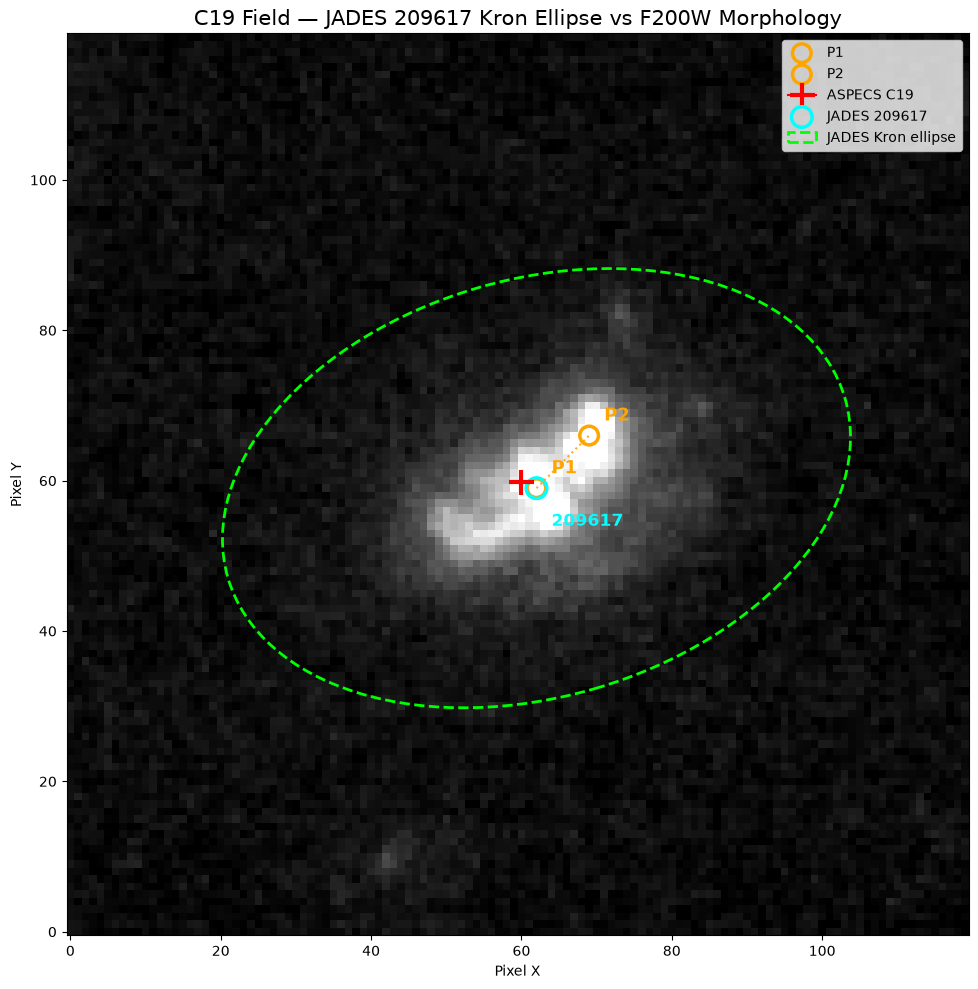

In [52]:
# ============================================================
# Phase 4R — Cell 3
# JADES Kron Ellipse Overlay
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 10))

# ------------------------------------------------------------
# Display the existing 120 x 120 F200W cutout
# ------------------------------------------------------------

vmin, vmax = np.nanpercentile(
    extended_cutout.data,
    [5, 99.5]
)

ax.imshow(
    extended_cutout.data,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

# ------------------------------------------------------------
# JADES source position
# ------------------------------------------------------------

jades_x = 62.0
jades_y = 59.0

# ------------------------------------------------------------
# P1 and P2 positions
# ------------------------------------------------------------

p1_x, p1_y = 62.0, 59.0
p2_x, p2_y = 69.0, 66.0

# C19 position relative to this cutout
c19_x, c19_y = 59.97, 59.81

# ------------------------------------------------------------
# Plot P1
# ------------------------------------------------------------

ax.scatter(
    p1_x,
    p1_y,
    marker="o",
    s=180,
    facecolors="none",
    edgecolors="orange",
    linewidths=2.5,
    label="P1"
)

ax.text(
    p1_x + 2,
    p1_y + 2,
    "P1",
    color="orange",
    fontsize=13,
    weight="bold"
)

# ------------------------------------------------------------
# Plot P2
# ------------------------------------------------------------

ax.scatter(
    p2_x,
    p2_y,
    marker="o",
    s=180,
    facecolors="none",
    edgecolors="orange",
    linewidths=2.5,
    label="P2"
)

ax.text(
    p2_x + 2,
    p2_y + 2,
    "P2",
    color="orange",
    fontsize=13,
    weight="bold"
)

# ------------------------------------------------------------
# C19
# ------------------------------------------------------------

ax.plot(
    c19_x,
    c19_y,
    marker="+",
    markersize=18,
    markeredgewidth=3,
    color="red",
    label="ASPECS C19"
)

# ------------------------------------------------------------
# JADES 209617
# ------------------------------------------------------------

ax.scatter(
    jades_x,
    jades_y,
    marker="o",
    s=220,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2.5,
    label="JADES 209617"
)

ax.text(
    jades_x + 2,
    jades_y - 5,
    "209617",
    color="cyan",
    fontsize=12,
    weight="bold"
)

# ------------------------------------------------------------
# JADES Kron ellipse
#
# A_KRON and B_KRON are in arcsec.
# Convert to pixels using the JWST pixel scale.
# ------------------------------------------------------------

pixel_scale_arcsec = 0.03123

A_pix = A / pixel_scale_arcsec
B_pix = B / pixel_scale_arcsec

ellipse = Ellipse(
    xy=(jades_x, jades_y),
    width=2 * A_pix,
    height=2 * B_pix,
    angle=90 - theta,
    edgecolor="lime",
    facecolor="none",
    linewidth=2.0,
    linestyle="--",
    label="JADES Kron ellipse"
)

ax.add_patch(ellipse)

# ------------------------------------------------------------
# P1-P2 connecting line
# ------------------------------------------------------------

ax.plot(
    [p1_x, p2_x],
    [p1_y, p2_y],
    color="orange",
    linestyle=":",
    linewidth=1.5,
    alpha=0.9
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_title(
    "C19 Field — JADES 209617 Kron Ellipse vs F200W Morphology",
    fontsize=15
)

ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")

ax.legend(
    loc="upper right",
    fontsize=10
)

plt.tight_layout()

plt.show()

PHASE 4S — P1/P2 SINGLE vs TWO-COMPONENT TEST
P1 = (62.0, 59.0)
P2 = (69.0, 66.0)
P1 → P2 separation = 9.90 pixels


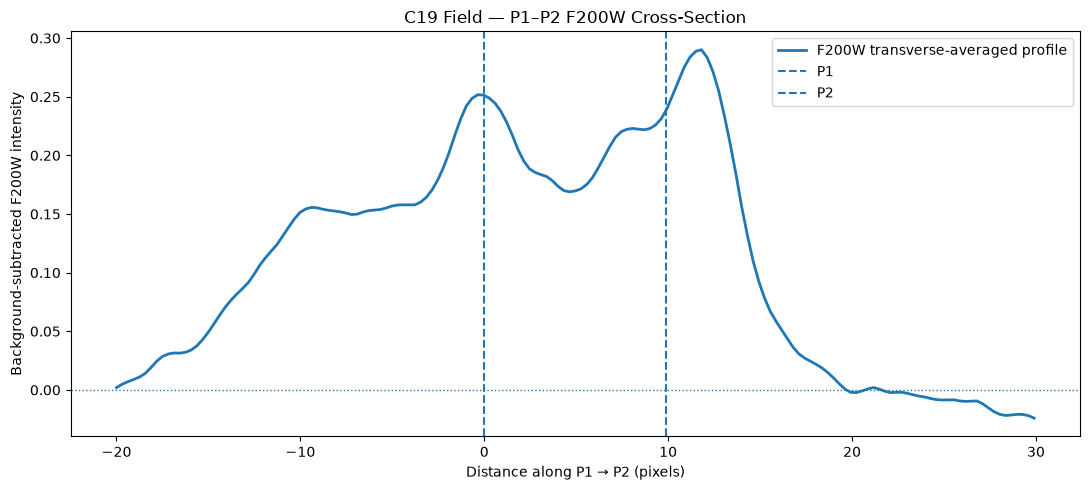


Estimated edge background = 0.168746
Profile maximum          = 0.458809


In [53]:
# ============================================================
# Phase 4S — Cell 1
# Extract P1–P2 F200W cross-section
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

print("============================================================")
print("PHASE 4S — P1/P2 SINGLE vs TWO-COMPONENT TEST")
print("============================================================")

# ------------------------------------------------------------
# P1 and P2 positions in the 120 x 120 cutout
# ------------------------------------------------------------

p1 = np.array([62.0, 59.0])   # x, y
p2 = np.array([69.0, 66.0])   # x, y

# ------------------------------------------------------------
# Direction from P1 to P2
# ------------------------------------------------------------

direction = p2 - p1
separation_pixels = np.linalg.norm(direction)
unit_direction = direction / separation_pixels

# Perpendicular direction
perp = np.array([
    -unit_direction[1],
     unit_direction[0]
])

print(f"P1 = ({p1[0]:.1f}, {p1[1]:.1f})")
print(f"P2 = ({p2[0]:.1f}, {p2[1]:.1f})")
print(f"P1 → P2 separation = {separation_pixels:.2f} pixels")

# ------------------------------------------------------------
# Sample from 20 pixels before P1 to 20 pixels after P2
# ------------------------------------------------------------

s = np.linspace(-20, separation_pixels + 20, 161)

# Width of transverse averaging strip
half_width = 1.5
transverse = np.linspace(-half_width, half_width, 7)

profile_values = []

for distance in s:

    center = p1 + distance * unit_direction

    positions = (
        center[:, None]
        + perp[:, None] * transverse[None, :]
    )

    values = map_coordinates(
        extended_cutout.data,
        [positions[1], positions[0]],
        order=1,
        mode="nearest"
    )

    profile_values.append(np.nanmean(values))

profile = np.array(profile_values)

# ------------------------------------------------------------
# Approximate background from profile ends
# ------------------------------------------------------------

edge_mask = (s < -12) | (s > separation_pixels + 12)

background = np.median(profile[edge_mask])

profile_sub = profile - background

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    s,
    profile_sub,
    linewidth=2,
    label="F200W transverse-averaged profile"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="P1"
)

ax.axvline(
    separation_pixels,
    linestyle="--",
    linewidth=1.5,
    label="P2"
)

ax.axhline(
    0,
    linestyle=":",
    linewidth=1
)

ax.set_xlabel("Distance along P1 → P2 (pixels)")
ax.set_ylabel("Background-subtracted F200W intensity")

ax.set_title(
    "C19 Field — P1–P2 F200W Cross-Section"
)

ax.legend()

plt.tight_layout()
plt.show()

print()
print(f"Estimated edge background = {background:.6f}")
print(f"Profile maximum          = {np.max(profile):.6f}")

PHASE 4S — SINGLE vs TWO-COMPONENT FIT

Fixed background:
0.148668

Fit region:
-7.8 to 19.9 pixels

------------------------------------------------------------
ONE-COMPONENT MODEL
------------------------------------------------------------
Amplitude = 0.255732
Center    = 3.935 pixels
Sigma     = 10.189 pixels

RSS = 2.184667e-01
RMS = 4.926873e-02
AIC = -535.884
BIC = -528.384

------------------------------------------------------------
TWO-COMPONENT MODEL
------------------------------------------------------------
P1 amplitude = 0.233436
P1 center    = 0.526 pixels
P1 sigma     = 8.564 pixels

P2 amplitude = 0.197896
P2 center    = 11.563 pixels
P2 sigma     = 2.358 pixels

Fitted component separation = 11.037 pixels
Angular separation          = 0.3447 arcsec

RSS = 2.867976e-02
RMS = 1.785116e-02
AIC = -712.624
BIC = -697.625

------------------------------------------------------------
MODEL COMPARISON
------------------------------------------------------------
ΔRSS = 1.8978

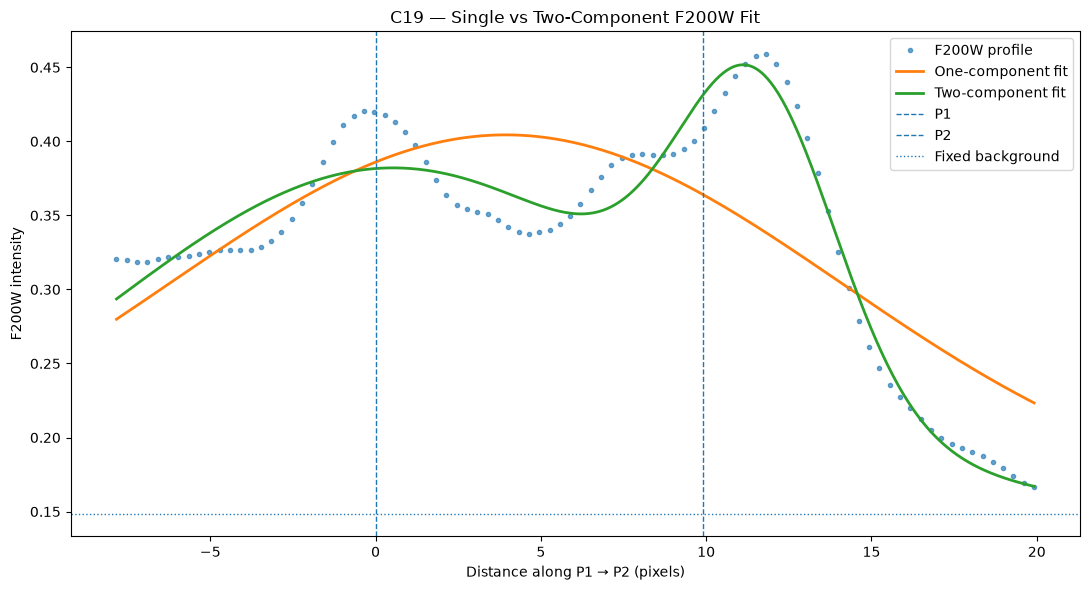

In [54]:
# ============================================================
# Phase 4S — Cell 2
# Single-component vs Two-component fit
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("============================================================")
print("PHASE 4S — SINGLE vs TWO-COMPONENT FIT")
print("============================================================")

# ------------------------------------------------------------
# Use independently measured image background
# ------------------------------------------------------------

fixed_background = 0.148668

# Use the raw transverse-averaged profile from Cell 1
y = profile.copy()
x = s.copy()

# ------------------------------------------------------------
# Restrict fit to the central galaxy region
#
# This avoids letting distant low-level structure dominate
# the fit.
# ------------------------------------------------------------

fit_mask = (x >= -8) & (x <= 20)

x_fit = x[fit_mask]
y_fit = y[fit_mask]

# ------------------------------------------------------------
# One-component model
# ------------------------------------------------------------

def one_component(x, A, mu, sigma):

    return (
        fixed_background
        + A * np.exp(
            -0.5 * ((x - mu) / sigma)**2
        )
    )

# ------------------------------------------------------------
# Two-component model
# ------------------------------------------------------------

def two_component(x, A1, mu1, sigma1,
                  A2, mu2, sigma2):

    return (
        fixed_background
        + A1 * np.exp(
            -0.5 * ((x - mu1) / sigma1)**2
        )
        + A2 * np.exp(
            -0.5 * ((x - mu2) / sigma2)**2
        )
    )

# ------------------------------------------------------------
# Initial guesses
# ------------------------------------------------------------

p0_one = [
    0.18,     # amplitude
    6.0,      # center
    8.0       # width
]

p0_two = [
    0.12,     # P1 amplitude
    0.0,      # P1 position
    5.0,      # P1 width

    0.14,     # P2 amplitude
    10.0,     # P2 position
    5.0       # P2 width
]

# ------------------------------------------------------------
# Bounds
# ------------------------------------------------------------

bounds_one = (
    [0.0, -8.0, 1.0],
    [1.0, 20.0, 20.0]
)

bounds_two = (
    [
        0.0, -5.0, 1.0,
        0.0, 5.0, 1.0
    ],
    [
        1.0, 8.0, 20.0,
        1.0, 20.0, 20.0
    ]
)

# ------------------------------------------------------------
# Fit models
# ------------------------------------------------------------

popt_one, pcov_one = curve_fit(
    one_component,
    x_fit,
    y_fit,
    p0=p0_one,
    bounds=bounds_one,
    maxfev=50000
)

popt_two, pcov_two = curve_fit(
    two_component,
    x_fit,
    y_fit,
    p0=p0_two,
    bounds=bounds_two,
    maxfev=50000
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

model_one = one_component(x_fit, *popt_one)
model_two = two_component(x_fit, *popt_two)

resid_one = y_fit - model_one
resid_two = y_fit - model_two

# ------------------------------------------------------------
# Residual statistics
# ------------------------------------------------------------

rss_one = np.sum(resid_one**2)
rss_two = np.sum(resid_two**2)

rms_one = np.sqrt(np.mean(resid_one**2))
rms_two = np.sqrt(np.mean(resid_two**2))

n = len(x_fit)
k_one = 3
k_two = 6

# AIC/BIC using Gaussian residual likelihood
aic_one = n * np.log(rss_one / n) + 2 * k_one
aic_two = n * np.log(rss_two / n) + 2 * k_two

bic_one = n * np.log(rss_one / n) + k_one * np.log(n)
bic_two = n * np.log(rss_two / n) + k_two * np.log(n)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nFixed background:")
print(f"{fixed_background:.6f}")

print("\nFit region:")
print(f"{x_fit.min():.1f} to {x_fit.max():.1f} pixels")

print("\n------------------------------------------------------------")
print("ONE-COMPONENT MODEL")
print("------------------------------------------------------------")

print(f"Amplitude = {popt_one[0]:.6f}")
print(f"Center    = {popt_one[1]:.3f} pixels")
print(f"Sigma     = {popt_one[2]:.3f} pixels")

print(f"\nRSS = {rss_one:.6e}")
print(f"RMS = {rms_one:.6e}")
print(f"AIC = {aic_one:.3f}")
print(f"BIC = {bic_one:.3f}")

print("\n------------------------------------------------------------")
print("TWO-COMPONENT MODEL")
print("------------------------------------------------------------")

print(f"P1 amplitude = {popt_two[0]:.6f}")
print(f"P1 center    = {popt_two[1]:.3f} pixels")
print(f"P1 sigma     = {popt_two[2]:.3f} pixels")

print(f"\nP2 amplitude = {popt_two[3]:.6f}")
print(f"P2 center    = {popt_two[4]:.3f} pixels")
print(f"P2 sigma     = {popt_two[5]:.3f} pixels")

fitted_sep = abs(popt_two[4] - popt_two[1])

print(f"\nFitted component separation = {fitted_sep:.3f} pixels")
print(f"Angular separation          = "
      f"{fitted_sep * 0.03123:.4f} arcsec")

print(f"\nRSS = {rss_two:.6e}")
print(f"RMS = {rms_two:.6e}")
print(f"AIC = {aic_two:.3f}")
print(f"BIC = {bic_two:.3f}")

print("\n------------------------------------------------------------")
print("MODEL COMPARISON")
print("------------------------------------------------------------")

print(f"ΔRSS = {rss_one - rss_two:.6e}")
print(f"ΔAIC = {aic_one - aic_two:.3f}")
print(f"ΔBIC = {bic_one - bic_two:.3f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

x_model = np.linspace(
    x_fit.min(),
    x_fit.max(),
    500
)

plt.figure(figsize=(11, 6))

plt.plot(
    x_fit,
    y_fit,
    "o",
    markersize=3,
    alpha=0.65,
    label="F200W profile"
)

plt.plot(
    x_model,
    one_component(x_model, *popt_one),
    linewidth=2,
    label="One-component fit"
)

plt.plot(
    x_model,
    two_component(x_model, *popt_two),
    linewidth=2,
    label="Two-component fit"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="P1"
)

plt.axvline(
    separation_pixels,
    linestyle="--",
    linewidth=1,
    label="P2"
)

plt.axhline(
    fixed_background,
    linestyle=":",
    linewidth=1,
    label="Fixed background"
)

plt.xlabel("Distance along P1 → P2 (pixels)")
plt.ylabel("F200W intensity")

plt.title(
    "C19 — Single vs Two-Component F200W Fit"
)

plt.legend()

plt.tight_layout()
plt.show()

PHASE 4T — 2-D SINGLE vs TWO-COMPONENT RESIDUAL TEST
Region size             : (40, 40)
Fixed background        : 0.148668

--- ONE-COMPONENT MODEL ---
Amplitude               : 0.243404
Center                  : (63.594, 59.856)
Sigma X                 : 10.963
Sigma Y                 : 5.747
Angle                   : 36.89 deg
RSS                     : 1.061504e+00
AIC                     : -11696.915
BIC                     : -11664.648

--- TWO-COMPONENT MODEL ---
Component 1:
  Amplitude             : 0.223279
  Center                : (62.424, 58.528)
  Sigma X               : 10.466
  Sigma Y               : 6.066
  Angle                 : 29.26 deg
Component 2:
  Amplitude             : 0.219984
  Center                : (69.881, 67.360)
  Sigma X               : 2.760
  Sigma Y               : 1.924
  Angle                 : 85.25 deg

Fitted component separation : 11.558 pixels
Angular separation          : 0.3610 arcsec

RSS                     : 5.693124e-01
AIC            

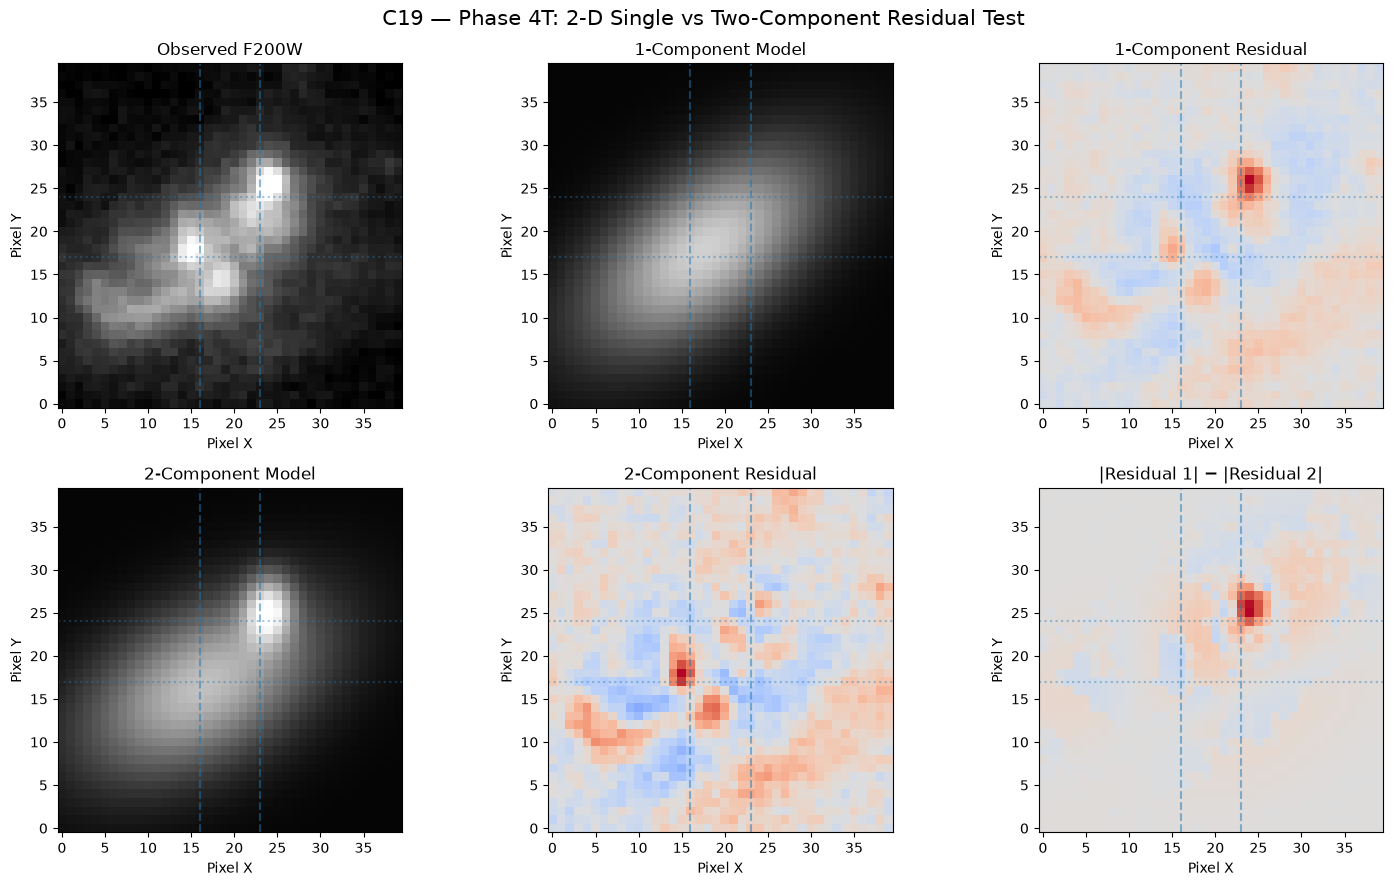

In [55]:
# ============================================================
# PHASE 4T — 2-D SINGLE vs TWO-COMPONENT RESIDUAL TEST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import least_squares

# ------------------------------------------------------------
# Image and known positions
# ------------------------------------------------------------

# extended_cutout is an Astropy Cutout2D object.
# Use .data to access the actual 2-D image array.
img = np.asarray(extended_cutout.data, dtype=float)

# P1 and P2 coordinates in the 120x120 cutout
p1 = np.array([62.0, 59.0])
p2 = np.array([69.0, 66.0])

background = 0.148668

# ------------------------------------------------------------
# Work on a 40 x 40 region centered between P1 and P2
# ------------------------------------------------------------

mid_x = (p1[0] + p2[0]) / 2
mid_y = (p1[1] + p2[1]) / 2

half_size = 20

x0 = int(round(mid_x)) - half_size
x1 = int(round(mid_x)) + half_size
y0 = int(round(mid_y)) - half_size
y1 = int(round(mid_y)) + half_size

region = img[y0:y1, x0:x1]

yy, xx = np.indices(region.shape)

# Coordinates in original 120x120 image
X = xx + x0
Y = yy + y0

# ------------------------------------------------------------
# Elliptical Gaussian
# ------------------------------------------------------------

def gaussian2d(x, y, amp, xc, yc, sx, sy, theta):
    """
    Elliptical 2-D Gaussian.
    theta is measured counter-clockwise in image pixel coordinates.
    """

    ct = np.cos(theta)
    st = np.sin(theta)

    dx = x - xc
    dy = y - yc

    xp =  ct * dx + st * dy
    yp = -st * dx + ct * dy

    return amp * np.exp(
        -0.5 * ((xp / sx)**2 + (yp / sy)**2)
    )

# ------------------------------------------------------------
# Model 1: one component
# Parameters:
# amp, xc, yc, sx, sy, theta
# ------------------------------------------------------------

def model_one(params):
    amp, xc, yc, sx, sy, theta = params

    return (
        background
        + gaussian2d(X, Y, amp, xc, yc, sx, sy, theta)
    )

def residual_one(params):
    return (model_one(params) - region).ravel()

# Initial guess centered near the flux distribution
p0_one = [
    0.25,          # amplitude
    mid_x,
    mid_y,
    9.0,           # sigma x
    6.0,           # sigma y
    np.deg2rad(32) # approximate morphology angle
]

bounds_one = (
    [0.0, x0, y0, 1.0, 1.0, -np.pi],
    [1.0, x1, y1, 25.0, 25.0, np.pi]
)

fit_one = least_squares(
    residual_one,
    p0_one,
    bounds=bounds_one
)

model1 = model_one(fit_one.x)
resid1 = region - model1

# ------------------------------------------------------------
# Model 2: two components
#
# Each component:
# amp, xc, yc, sx, sy, theta
# ------------------------------------------------------------

def model_two(params):

    g1 = gaussian2d(
        X, Y,
        params[0], params[1], params[2],
        params[3], params[4], params[5]
    )

    g2 = gaussian2d(
        X, Y,
        params[6], params[7], params[8],
        params[9], params[10], params[11]
    )

    return background + g1 + g2

def residual_two(params):
    return (model_two(params) - region).ravel()

# Initial components near P1 and P2
p0_two = [
    0.23, p1[0], p1[1], 7.0, 5.0, np.deg2rad(32),
    0.20, p2[0], p2[1], 4.0, 3.0, np.deg2rad(32)
]

bounds_two = (
    [
        0.0, x0, y0, 1.0, 1.0, -np.pi,
        0.0, x0, y0, 1.0, 1.0, -np.pi
    ],
    [
        1.0, x1, y1, 25.0, 25.0, np.pi,
        1.0, x1, y1, 25.0, 25.0, np.pi
    ]
)

fit_two = least_squares(
    residual_two,
    p0_two,
    bounds=bounds_two
)

model2 = model_two(fit_two.x)
resid2 = region - model2

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

rss1 = np.sum(resid1**2)
rss2 = np.sum(resid2**2)

n = region.size
k1 = len(fit_one.x)
k2 = len(fit_two.x)

aic1 = n * np.log(rss1 / n) + 2 * k1
aic2 = n * np.log(rss2 / n) + 2 * k2

bic1 = n * np.log(rss1 / n) + k1 * np.log(n)
bic2 = n * np.log(rss2 / n) + k2 * np.log(n)

# ------------------------------------------------------------
# Component positions and separation
# ------------------------------------------------------------

x1_fit, y1_fit = fit_two.x[1], fit_two.x[2]
x2_fit, y2_fit = fit_two.x[7], fit_two.x[8]

component_sep = np.hypot(
    x2_fit - x1_fit,
    y2_fit - y1_fit
)

pixel_scale = 0.03123

angular_sep = component_sep * pixel_scale

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 60)
print("PHASE 4T — 2-D SINGLE vs TWO-COMPONENT RESIDUAL TEST")
print("=" * 60)

print(f"Region size             : {region.shape}")
print(f"Fixed background        : {background:.6f}")

print("\n--- ONE-COMPONENT MODEL ---")
print(f"Amplitude               : {fit_one.x[0]:.6f}")
print(f"Center                  : ({fit_one.x[1]:.3f}, "
      f"{fit_one.x[2]:.3f})")
print(f"Sigma X                 : {fit_one.x[3]:.3f}")
print(f"Sigma Y                 : {fit_one.x[4]:.3f}")
print(f"Angle                   : "
      f"{np.rad2deg(fit_one.x[5]):.2f} deg")
print(f"RSS                     : {rss1:.6e}")
print(f"AIC                     : {aic1:.3f}")
print(f"BIC                     : {bic1:.3f}")

print("\n--- TWO-COMPONENT MODEL ---")

print("Component 1:")
print(f"  Amplitude             : {fit_two.x[0]:.6f}")
print(f"  Center                : ({x1_fit:.3f}, {y1_fit:.3f})")
print(f"  Sigma X               : {fit_two.x[3]:.3f}")
print(f"  Sigma Y               : {fit_two.x[4]:.3f}")
print(f"  Angle                 : "
      f"{np.rad2deg(fit_two.x[5]):.2f} deg")

print("Component 2:")
print(f"  Amplitude             : {fit_two.x[6]:.6f}")
print(f"  Center                : ({x2_fit:.3f}, {y2_fit:.3f})")
print(f"  Sigma X               : {fit_two.x[9]:.3f}")
print(f"  Sigma Y               : {fit_two.x[10]:.3f}")
print(f"  Angle                 : "
      f"{np.rad2deg(fit_two.x[11]):.2f} deg")

print(f"\nFitted component separation : "
      f"{component_sep:.3f} pixels")
print(f"Angular separation          : "
      f"{angular_sep:.4f} arcsec")

print(f"\nRSS                     : {rss2:.6e}")
print(f"AIC                     : {aic2:.3f}")
print(f"BIC                     : {bic2:.3f}")

print("\n--- MODEL IMPROVEMENT ---")
print(f"Delta RSS                : {rss1 - rss2:.6e}")
print(f"RSS reduction            : "
      f"{100*(1-rss2/rss1):.2f}%")
print(f"Delta AIC                : {aic1-aic2:.3f}")
print(f"Delta BIC                : {bic1-bic2:.3f}")

# ------------------------------------------------------------
# Display the six-panel diagnostic
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

vmin = np.percentile(region, 2)
vmax = np.percentile(region, 99.5)

# Observed
axes[0,0].imshow(
    region,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
axes[0,0].set_title("Observed F200W")

# One-component model
axes[0,1].imshow(
    model1,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
axes[0,1].set_title("1-Component Model")

# One-component residual
r = np.max(np.abs(resid1))
axes[0,2].imshow(
    resid1,
    origin="lower",
    cmap="coolwarm",
    vmin=-r,
    vmax=r
)
axes[0,2].set_title("1-Component Residual")

# Two-component model
axes[1,0].imshow(
    model2,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
axes[1,0].set_title("2-Component Model")

# Two-component residual
r = np.max(np.abs(resid2))
axes[1,1].imshow(
    resid2,
    origin="lower",
    cmap="coolwarm",
    vmin=-r,
    vmax=r
)
axes[1,1].set_title("2-Component Residual")

# Difference between residuals
difference = np.abs(resid1) - np.abs(resid2)

r = np.max(np.abs(difference))
axes[1,2].imshow(
    difference,
    origin="lower",
    cmap="coolwarm",
    vmin=-r,
    vmax=r
)
axes[1,2].set_title("|Residual 1| − |Residual 2|")

# ------------------------------------------------------------
# Mark P1/P2 on observed image
# ------------------------------------------------------------

for ax in [axes[0,0], axes[0,1], axes[0,2],
           axes[1,0], axes[1,1], axes[1,2]]:

    ax.axvline(p1[0] - x0, ls="--", alpha=0.5)
    ax.axvline(p2[0] - x0, ls="--", alpha=0.5)

    ax.axhline(p1[1] - y0, ls=":", alpha=0.4)
    ax.axhline(p2[1] - y0, ls=":", alpha=0.4)

    ax.set_xlabel("Pixel X")
    ax.set_ylabel("Pixel Y")

plt.suptitle(
    "C19 — Phase 4T: 2-D Single vs Two-Component Residual Test",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# PHASE 4U — PSF-AWARE MORPHOLOGY
# STEP 1: Check available PSF resources
# ============================================================

import os
import glob

print("=" * 60)
print("PHASE 4U — AVAILABLE F200W PSF RESOURCES")
print("=" * 60)

# Search the project for PSF-related files
project_root = "/home/glenn/Projects/CosmicIntelligenceLab"

patterns = [
    "**/*psf*",
    "**/*PSF*",
    "**/*f200w*psf*",
    "**/*F200W*PSF*"
]

psf_files = []

for pattern in patterns:
    psf_files.extend(
        glob.glob(
            os.path.join(project_root, pattern),
            recursive=True
        )
    )

# Remove duplicates
psf_files = sorted(set(psf_files))

if psf_files:
    print(f"\nFound {len(psf_files)} PSF-related files:\n")

    for path in psf_files:
        print(path)

else:
    print("\nNo existing PSF files found in the project.")

print("\n" + "=" * 60)
print("NEXT STEP")
print("=" * 60)

print("""
We will use an existing F200W PSF if one is already available.
Otherwise, we will construct an appropriate JWST F200W PSF
for the modelling step.
""")

PHASE 4U — AVAILABLE F200W PSF RESOURCES

No existing PSF files found in the project.

NEXT STEP

We will use an existing F200W PSF if one is already available.
Otherwise, we will construct an appropriate JWST F200W PSF
for the modelling step.



In [57]:
# ============================================================
# PHASE 4U — STEP 2
# Check whether WebbPSF is available
# ============================================================

import importlib.util

print("=" * 60)
print("PHASE 4U — JWST PSF MODELING ENVIRONMENT")
print("=" * 60)

webbpsf_available = importlib.util.find_spec("webbpsf") is not None

if webbpsf_available:
    import webbpsf
    print("\nWebbPSF: AVAILABLE")
    print("Version:", getattr(webbpsf, "__version__", "unknown"))
else:
    print("\nWebbPSF: NOT INSTALLED")

# Also check the underlying astronomy packages we will need
packages = [
    "astropy",
    "numpy",
    "scipy",
    "photutils"
]

print("\nSupporting packages:")

for package in packages:
    available = importlib.util.find_spec(package) is not None
    print(f"  {package:12s}: {'AVAILABLE' if available else 'NOT FOUND'}")

print("\n" + "=" * 60)

if webbpsf_available:
    print("NEXT STEP:")
    print("Construct a JWST/NIRCam F200W PSF.")
else:
    print("NEXT STEP:")
    print("Install WebbPSF before constructing the PSF.")

PHASE 4U — JWST PSF MODELING ENVIRONMENT

WebbPSF: AVAILABLE
Version: 2.2.0

Supporting packages:
  astropy     : AVAILABLE
  numpy       : AVAILABLE
  scipy       : AVAILABLE
  photutils   : AVAILABLE

NEXT STEP:
Construct a JWST/NIRCam F200W PSF.


/tmp/ipykernel_184172/12652551.py:15: DeprecationWarning: "
        This message is for information only and WebbPSF will continue to function as normal.
        The WebbPSF library has been moved/renamed to STPSF.
        Please see https://stpsf.readthedocs.io/en/stable/ for more information.
        WebbPSF is now an alias of STPSF and is running code from the STPSF library.
        
  import webbpsf


In [58]:
# ============================================================
# PHASE 4U — STEP 4
# Initialize STPSF and inspect the reference data
# ============================================================

import os
import stpsf

print("=" * 60)
print("PHASE 4U — STPSF INITIALIZATION")
print("=" * 60)

print("STPSF version:", stpsf.__version__)

print("\nCreating NIRCam instrument model...")

try:
    nc = stpsf.NIRCam()

    print("NIRCam model: SUCCESS")
    print("STPSF data path:")
    print(os.environ.get("STPSF_PATH", "not explicitly set"))

except Exception as e:
    print("\nSTPSF initialization produced an error:")
    print(type(e).__name__)
    print(e)

PHASE 4U — STPSF INITIALIZATION
STPSF version: 2.2.0

Creating NIRCam instrument model...

STPSF initialization produced an error:
OSError
Couldn't read the version number from version.txt. (Do you need to update the STPSF data? See https://stpsf.readthedocs.io/en/stable/installation.html#data-install for a link to the latest version.)

 ***********  ERROR  ******  ERROR  ******  ERROR  ******  ERROR  ***********
 *                                                                          *
 *  STPSF requires several data files to operate.                         *
 *  These files could not be located automatically at this time, or this    *
 *  version of the software requires a newer set of reference files than    *
 *  you have installed.  For more details see:                              *
 *                                                                          *
 *        https://stpsf.readthedocs.io/en/stable/installation.html        *
 *                                       

In [59]:
# ============================================================
# PHASE 4U — STEP 5
# Construct JWST NIRCam F200W PSF
# ============================================================

import stpsf
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("PHASE 4U — JWST NIRCam F200W PSF")
print("=" * 60)

# ------------------------------------------------------------
# Create NIRCam instrument model
# ------------------------------------------------------------

nc = stpsf.NIRCam()

# F200W filter
nc.filter = "F200W"

# ------------------------------------------------------------
# Generate oversampled PSF
# ------------------------------------------------------------

psf_hdul = nc.calc_psf(
    oversample=4,
    fov_arcsec=2.0
)

print("\nPSF generated successfully.")

# ------------------------------------------------------------
# Inspect the PSF
# ------------------------------------------------------------

psf_data = psf_hdul[0].data

print("PSF array shape:", psf_data.shape)
print("PSF maximum   :", np.nanmax(psf_data))
print("PSF sum       :", np.nansum(psf_data))

# ------------------------------------------------------------
# Display PSF
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.imshow(
    psf_data,
    origin="lower",
    cmap="gray"
)

plt.colorbar(label="Relative intensity")

plt.title(
    "JWST NIRCam F200W PSF\nSTPSF 2.2.0"
)

plt.xlabel("PSF pixel")
plt.ylabel("PSF pixel")

plt.tight_layout()
plt.show()

/home/glenn/anaconda3/envs/cosmic_ai/lib/python3.12/site-packages/stpsf/utils.py:920: SyntaxWarning: invalid escape sequence '\w'
  ind_i_let = re.search('\w',


PHASE 4U — JWST NIRCam F200W PSF


OSError: Couldn't read the version number from version.txt. (Do you need to update the STPSF data? See https://stpsf.readthedocs.io/en/stable/installation.html#data-install for a link to the latest version.)

 ***********  ERROR  ******  ERROR  ******  ERROR  ******  ERROR  ***********
 *                                                                          *
 *  STPSF requires several data files to operate.                         *
 *  These files could not be located automatically at this time, or this    *
 *  version of the software requires a newer set of reference files than    *
 *  you have installed.  For more details see:                              *
 *                                                                          *
 *        https://stpsf.readthedocs.io/en/stable/installation.html        *
 *                                                                          *
 *  under "Installing the Required Data Files".                             *
 *  STPSF will 

In [ ]:
# ============================================================
# PHASE 4U — STEP 6
# Convert the 4x oversampled PSF to detector sampling
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("PHASE 4U — PSF SAMPLING / NORMALIZATION")
print("=" * 60)

# ------------------------------------------------------------
# Inspect PSF metadata
# ------------------------------------------------------------

hdr = psf_hdul[0].header

print("\nRelevant PSF header information:")

for key in [
    "PIXELSCL",
    "OVERSAMP",
    "FOV",
    "FILTNAME",
    "DETNAME"
]:
    if key in hdr:
        print(f"{key:12s}: {hdr[key]}")

# ------------------------------------------------------------
# Known science-image pixel scale
# ------------------------------------------------------------

science_pixel_scale = 0.03123

# STPSF was generated at oversample=4
oversample = 4

oversampled_pixel_scale = science_pixel_scale / oversample

print("\nScience image pixel scale : "
      f"{science_pixel_scale:.5f} arcsec/pixel")

print("STPSF oversampling        : "
      f"{oversample}x")

print("Approx. oversampled scale : "
      f"{oversampled_pixel_scale:.5f} arcsec/pixel")

# ------------------------------------------------------------
# Extract PSF
# ------------------------------------------------------------

psf_os = np.asarray(psf_hdul[0].data, dtype=float)

# Remove any negative numerical values
psf_os = np.maximum(psf_os, 0)

# ------------------------------------------------------------
# Normalize oversampled PSF
# ------------------------------------------------------------

psf_os /= np.sum(psf_os)

print("\nOversampled PSF:")
print("Shape              :", psf_os.shape)
print("Normalized sum     :", np.sum(psf_os))

# ------------------------------------------------------------
# Bin 4x4 pixels to detector sampling
#
# We SUM, rather than average, because flux must be conserved.
# ------------------------------------------------------------

ny, nx = psf_os.shape

ny_trim = (ny // oversample) * oversample
nx_trim = (nx // oversample) * oversample

psf_trim = psf_os[:ny_trim, :nx_trim]

psf_native = psf_trim.reshape(
    ny_trim // oversample,
    oversample,
    nx_trim // oversample,
    oversample
).sum(axis=(1, 3))

# Normalize again
psf_native /= np.sum(psf_native)

print("\nDetector-sampled PSF:")
print("Shape              :", psf_native.shape)
print("Normalized sum     :", np.sum(psf_native))
print("Maximum            :", np.max(psf_native))

# ------------------------------------------------------------
# Find PSF center
# ------------------------------------------------------------

peak_y, peak_x = np.unravel_index(
    np.argmax(psf_native),
    psf_native.shape
)

print("\nPSF peak pixel      : "
      f"({peak_x}, {peak_y})")

# ------------------------------------------------------------
# Display detector-sampled PSF
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

extent = [
    0,
    psf_native.shape[1] * science_pixel_scale,
    0,
    psf_native.shape[0] * science_pixel_scale
]

plt.imshow(
    psf_native,
    origin="lower",
    cmap="gray",
    extent=extent
)

plt.colorbar(label="Normalized intensity")

plt.xlabel("Arcsec")
plt.ylabel("Arcsec")

plt.title(
    "JWST NIRCam F200W PSF — Detector Sampling"
)

plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# PHASE 4U — STEP 7
# PSF-CONVOLVED 2-D SINGLE vs TWO-COMPONENT MODEL TEST
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy.signal import fftconvolve
from scipy.optimize import least_squares

print("=" * 64)
print("PHASE 4U — STEP 7")
print("PSF-CONVOLVED 2-D SINGLE vs TWO-COMPONENT MODEL TEST")
print("=" * 64)


# ============================================================
# 1. JWST F200W OBSERVATION
# ============================================================

fits_path = (
    "/home/glenn/Projects/CosmicIntelligenceLab/"
    "data/raw/jwst/"
    "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

if not os.path.exists(fits_path):
    raise FileNotFoundError(
        f"JWST FITS file not found:\n{fits_path}"
    )

print("\nJWST file:")
print(fits_path)


# ============================================================
# 2. READ SCIENCE IMAGE AND HEADER
# ============================================================

with fits.open(fits_path) as hdul:

    science = np.asarray(
        hdul["SCI"].data,
        dtype=float
    )

    sci_header = hdul["SCI"].header

    primary_header = hdul[0].header

    detector = (
        sci_header.get("DETECTOR")
        or primary_header.get("DETECTOR")
    )

    instrument = (
        sci_header.get("INSTRUME")
        or primary_header.get("INSTRUME")
    )

    filter_name = (
        sci_header.get("FILTER")
        or primary_header.get("FILTER")
        or "F200W"
    )


print("\nObservation information:")
print("Instrument :", instrument)
print("Detector   :", detector)
print("Filter     :", filter_name)
print("SCI shape  :", science.shape)


# ============================================================
# 3. KNOWN JWST DETECTOR POSITIONS
#
# From our Phase 4Q astrometric solution:
#
# P1 = (3879.000, 315.000)
# P2 = (3886.000, 322.000)
# ============================================================

p1_global = np.array([
    3879.000,
    315.000
])

p2_global = np.array([
    3886.000,
    322.000
])


# ============================================================
# 4. EXTRACT EXACT 40 x 40 REGION
#
# The region is chosen so that:
#
# P1 -> (16,17)
# P2 -> (23,24)
# ============================================================

x0 = 3863
y0 = 298

region_size = 40

data = science[
    y0:y0 + region_size,
    x0:x0 + region_size
].copy()


if data.shape != (40, 40):
    raise RuntimeError(
        f"Unexpected cutout shape: {data.shape}"
    )


# Convert global detector coordinates to local cutout coordinates.

p1 = p1_global - np.array([x0, y0])
p2 = p2_global - np.array([x0, y0])


print("\n40 x 40 analysis region:")
print("Origin (global pixel):", (x0, y0))
print("P1 local             :", p1)
print("P2 local             :", p2)


# ============================================================
# 5. PIXEL SCALE
# ============================================================

science_pixel_scale = 0.03123

p1_p2_separation_pixels = np.sqrt(
    np.sum((p2 - p1)**2)
)

p1_p2_separation_arcsec = (
    p1_p2_separation_pixels *
    science_pixel_scale
)

print("\nGeometry:")
print(
    "P1-P2 separation      : "
    f"{p1_p2_separation_pixels:.4f} pixels"
)

print(
    "P1-P2 angular spacing : "
    f"{p1_p2_separation_arcsec:.4f} arcsec"
)


# ============================================================
# 6. BACKGROUND
#
# Phase 4S / 4T measured:
# Background = 0.148668
# ============================================================

background = 0.148668

data_sub = data - background

print("\nBackground:")
print(f"{background:.6f}")


# ============================================================
# 7. LOAD / GENERATE JWST F200W DETECTOR-SAMPLED PSF
# ============================================================

print("\n" + "-" * 64)
print("PSF preparation")
print("-" * 64)


# If psf_native already exists from the previous Phase 4U
# cells, use it. Otherwise construct a new STPSF model.

try:

    psf = np.asarray(
        psf_native,
        dtype=float
    )

    print("Using existing detector-sampled PSF.")

except NameError:

    print(
        "No existing detector-sampled PSF found."
    )

    print(
        "Generating JWST NIRCam F200W PSF with STPSF..."
    )

    import stpsf

    nircam = stpsf.NIRCam()

    nircam.filter = "F200W"

    # Use detector from the actual FITS header when available.
    if detector is not None:
        try:
            nircam.detector = detector
            print(
                "STPSF detector:",
                detector
            )
        except Exception as exc:
            print(
                "Could not assign FITS detector directly."
            )
            print(
                "STPSF message:",
                exc
            )

    psf_result = nircam.calc_psf(
        oversample=4,
        fov_pixels=64
    )

    # DET_SAMP is the detector-sampled result.
    psf = np.asarray(
        psf_result["DET_SAMP"].data,
        dtype=float
    )


# ============================================================
# 8. PSF CLEANUP / NORMALIZATION
# ============================================================

psf = np.nan_to_num(
    psf,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

psf = np.maximum(
    psf,
    0.0
)

if psf.sum() <= 0:
    raise RuntimeError(
        "PSF contains no positive flux."
    )

psf /= psf.sum()


print("\nPSF:")
print("Shape          :", psf.shape)
print("Normalized sum :", psf.sum())
print("Maximum        :", psf.max())


# ============================================================
# 9. PIXEL GRID
# ============================================================

ny, nx = data.shape

yy, xx = np.mgrid[
    0:ny,
    0:nx
]


# ============================================================
# 10. 2-D ELLIPTICAL GAUSSIAN
# ============================================================

def gaussian2d(
    x,
    y,
    amplitude,
    x0,
    y0,
    sigma_x,
    sigma_y,
    theta
):

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    dx = x - x0
    dy = y - y0

    xr = (
        cos_t * dx
        + sin_t * dy
    )

    yr = (
        -sin_t * dx
        + cos_t * dy
    )

    return amplitude * np.exp(
        -0.5 * (
            (xr / sigma_x)**2
            +
            (yr / sigma_y)**2
        )
    )


# ============================================================
# 11. PSF CONVOLUTION
# ============================================================

def convolve_psf(model):

    return fftconvolve(
        model,
        psf,
        mode="same"
    )


# ============================================================
# 12. ONE-COMPONENT MODEL
# ============================================================

def model_one(params):

    (
        amplitude,
        x0,
        y0,
        sigma_x,
        sigma_y,
        theta
    ) = params

    intrinsic = gaussian2d(
        xx,
        yy,
        amplitude,
        x0,
        y0,
        sigma_x,
        sigma_y,
        theta
    )

    return convolve_psf(
        intrinsic
    )


# ============================================================
# 13. TWO-COMPONENT MODEL
# ============================================================

def model_two(params):

    (
        amp1,
        x1,
        y1,
        sx1,
        sy1,
        theta1,

        amp2,
        x2,
        y2,
        sx2,
        sy2,
        theta2
    ) = params

    component1 = gaussian2d(
        xx,
        yy,
        amp1,
        x1,
        y1,
        sx1,
        sy1,
        theta1
    )

    component2 = gaussian2d(
        xx,
        yy,
        amp2,
        x2,
        y2,
        sx2,
        sy2,
        theta2
    )

    intrinsic = (
        component1
        +
        component2
    )

    return convolve_psf(
        intrinsic
    )


# ============================================================
# 14. FIT MASK
# ============================================================

mask = np.isfinite(
    data_sub
)

observed = data_sub[mask]


# ============================================================
# 15. RESIDUAL FUNCTIONS
# ============================================================

def residual_one(params):

    return (
        model_one(params)[mask]
        -
        observed
    )


def residual_two(params):

    return (
        model_two(params)[mask]
        -
        observed
    )


# ============================================================
# 16. INITIAL ONE-COMPONENT PARAMETERS
#
# Based on Phase 4T morphology.
# ============================================================

p0_one = np.array([
    0.24,                 # amplitude
    17.0,                 # X
    18.0,                 # Y
    9.0,                  # sigma X
    5.5,                  # sigma Y
    np.deg2rad(35.0)      # angle
])


# ============================================================
# 17. INITIAL TWO-COMPONENT PARAMETERS
#
# Component 1 ~ P1
# Component 2 ~ P2
# ============================================================

p0_two = np.array([

    # Component 1
    0.22,
    16.5,
    18.0,
    8.5,
    5.5,
    np.deg2rad(30.0),

    # Component 2
    0.20,
    23.0,
    25.0,
    2.5,
    2.0,
    np.deg2rad(85.0)
])


# ============================================================
# 18. PARAMETER BOUNDS
# ============================================================

lower_one = np.array([
    0.0,
    0.0,
    0.0,
    0.5,
    0.5,
    -np.pi
])

upper_one = np.array([
    2.0,
    nx - 1,
    ny - 1,
    30.0,
    30.0,
    np.pi
])


lower_two = np.array([

    # Component 1
    0.0,
    0.0,
    0.0,
    0.5,
    0.5,
    -np.pi,

    # Component 2
    0.0,
    0.0,
    0.0,
    0.5,
    0.5,
    -np.pi
])


upper_two = np.array([

    # Component 1
    2.0,
    nx - 1,
    ny - 1,
    30.0,
    30.0,
    np.pi,

    # Component 2
    2.0,
    nx - 1,
    ny - 1,
    15.0,
    15.0,
    np.pi
])


# ============================================================
# 19. PERFORM FITS
# ============================================================

print("\n" + "-" * 64)
print("Fitting PSF-convolved models...")
print("-" * 64)


fit_one = least_squares(
    residual_one,
    p0_one,
    bounds=(
        lower_one,
        upper_one
    ),
    max_nfev=5000
)


fit_two = least_squares(
    residual_two,
    p0_two,
    bounds=(
        lower_two,
        upper_two
    ),
    max_nfev=10000
)


# ============================================================
# 20. BEST-FIT MODELS
# ============================================================

best_one = model_one(
    fit_one.x
)

best_two = model_two(
    fit_two.x
)


# ============================================================
# 21. RESIDUALS
# ============================================================

residual_image_one = (
    data_sub
    -
    best_one
)

residual_image_two = (
    data_sub
    -
    best_two
)


# ============================================================
# 22. STATISTICS
# ============================================================

rss_one = np.sum(
    residual_image_one[mask]**2
)

rss_two = np.sum(
    residual_image_two[mask]**2
)

n_data = np.sum(mask)

k_one = len(
    fit_one.x
)

k_two = len(
    fit_two.x
)


aic_one = (
    n_data * np.log(rss_one / n_data)
    +
    2 * k_one
)

aic_two = (
    n_data * np.log(rss_two / n_data)
    +
    2 * k_two
)


bic_one = (
    n_data * np.log(rss_one / n_data)
    +
    k_one * np.log(n_data)
)

bic_two = (
    n_data * np.log(rss_two / n_data)
    +
    k_two * np.log(n_data)
)


delta_rss = (
    rss_one
    -
    rss_two
)

rss_reduction = (
    100.0 *
    delta_rss /
    rss_one
)

delta_aic = (
    aic_one
    -
    aic_two
)

delta_bic = (
    bic_one
    -
    bic_two
)


# ============================================================
# 23. FITTED COMPONENT SEPARATION
# ============================================================

component_separation = np.sqrt(

    (
        fit_two.x[7]
        -
        fit_two.x[1]
    )**2

    +

    (
        fit_two.x[8]
        -
        fit_two.x[2]
    )**2
)

component_separation_arcsec = (
    component_separation
    *
    science_pixel_scale
)


# ============================================================
# 24. PRINT RESULTS
# ============================================================

print("\n")
print("=" * 64)
print("PHASE 4U — PSF-CONVOLVED MODEL RESULTS")
print("=" * 64)


print("\n--- ONE-COMPONENT MODEL ---")

print(
    f"Amplitude : {fit_one.x[0]:.6f}"
)

print(
    f"Center    : "
    f"({fit_one.x[1]:.3f}, "
    f"{fit_one.x[2]:.3f})"
)

print(
    f"Sigma X   : {fit_one.x[3]:.3f}"
)

print(
    f"Sigma Y   : {fit_one.x[4]:.3f}"
)

print(
    f"Angle     : "
    f"{np.rad2deg(fit_one.x[5]):.3f} deg"
)

print(
    f"RSS       : {rss_one:.6e}"
)

print(
    f"RMS       : "
    f"{np.sqrt(rss_one / n_data):.6e}"
)

print(
    f"AIC       : {aic_one:.3f}"
)

print(
    f"BIC       : {bic_one:.3f}"
)


print("\n--- TWO-COMPONENT MODEL ---")


print("\nComponent 1:")

print(
    f"Amplitude : {fit_two.x[0]:.6f}"
)

print(
    f"Center    : "
    f"({fit_two.x[1]:.3f}, "
    f"{fit_two.x[2]:.3f})"
)

print(
    f"Sigma X   : {fit_two.x[3]:.3f}"
)

print(
    f"Sigma Y   : {fit_two.x[4]:.3f}"
)

print(
    f"Angle     : "
    f"{np.rad2deg(fit_two.x[5]):.3f} deg"
)


print("\nComponent 2:")

print(
    f"Amplitude : {fit_two.x[6]:.6f}"
)

print(
    f"Center    : "
    f"({fit_two.x[7]:.3f}, "
    f"{fit_two.x[8]:.3f})"
)

print(
    f"Sigma X   : {fit_two.x[9]:.3f}"
)

print(
    f"Sigma Y   : {fit_two.x[10]:.3f}"
)

print(
    f"Angle     : "
    f"{np.rad2deg(fit_two.x[11]):.3f} deg"
)


print("\nFitted component separation:")
print(
    f"{component_separation:.3f} pixels"
)

print(
    f"{component_separation_arcsec:.4f} arcsec"
)


print("\nTwo-component statistics:")

print(
    f"RSS       : {rss_two:.6e}"
)

print(
    f"RMS       : "
    f"{np.sqrt(rss_two / n_data):.6e}"
)

print(
    f"AIC       : {aic_two:.3f}"
)

print(
    f"BIC       : {bic_two:.3f}"
)


print("\n--- MODEL IMPROVEMENT ---")

print(
    f"Delta RSS       : "
    f"{delta_rss:.6e}"
)

print(
    f"RSS reduction   : "
    f"{rss_reduction:.2f}%"
)

print(
    f"Delta AIC       : "
    f"{delta_aic:.3f}"
)

print(
    f"Delta BIC       : "
    f"{delta_bic:.3f}"
)


# ============================================================
# 25. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)


# ------------------------------------------------------------
# Common display limits
# ------------------------------------------------------------

vmin = np.percentile(
    data_sub,
    2
)

vmax = np.percentile(
    data_sub,
    99
)


res_limit = np.percentile(
    np.abs(
        np.concatenate([
            residual_image_one.ravel(),
            residual_image_two.ravel()
        ])
    ),
    98
)


# ------------------------------------------------------------
# Panel 1 — observed
# ------------------------------------------------------------

axes[0, 0].imshow(
    data_sub,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

axes[0, 0].set_title(
    "Observed F200W"
)


# ------------------------------------------------------------
# Panel 2 — one component
# ------------------------------------------------------------

axes[0, 1].imshow(
    best_one,
    origin="lower",
    cmap="gray"
)

axes[0, 1].set_title(
    "PSF-convolved 1-component"
)


# ------------------------------------------------------------
# Panel 3 — one-component residual
# ------------------------------------------------------------

axes[0, 2].imshow(
    residual_image_one,
    origin="lower",
    cmap="coolwarm",
    vmin=-res_limit,
    vmax=res_limit
)

axes[0, 2].set_title(
    "1-component residual"
)


# ------------------------------------------------------------
# Panel 4 — two components
# ------------------------------------------------------------

axes[1, 0].imshow(
    best_two,
    origin="lower",
    cmap="gray"
)

axes[1, 0].set_title(
    "PSF-convolved 2-component"
)


# ------------------------------------------------------------
# Panel 5 — two-component residual
# ------------------------------------------------------------

axes[1, 1].imshow(
    residual_image_two,
    origin="lower",
    cmap="coolwarm",
    vmin=-res_limit,
    vmax=res_limit
)

axes[1, 1].set_title(
    "2-component residual"
)


# ------------------------------------------------------------
# Panel 6 — residual improvement
# ------------------------------------------------------------

residual_difference = (
    np.abs(residual_image_one)
    -
    np.abs(residual_image_two)
)

diff_limit = np.percentile(
    np.abs(residual_difference),
    98
)

axes[1, 2].imshow(
    residual_difference,
    origin="lower",
    cmap="coolwarm",
    vmin=-diff_limit,
    vmax=diff_limit
)

axes[1, 2].set_title(
    "|Residual 1| − |Residual 2|"
)


# ============================================================
# 26. MARK P1 / P2 ON EVERY PANEL
# ============================================================

for ax in axes.flat:

    ax.axvline(
        p1[0],
        linestyle="--",
        alpha=0.55
    )

    ax.axvline(
        p2[0],
        linestyle="--",
        alpha=0.55
    )

    ax.axhline(
        p1[1],
        linestyle=":",
        alpha=0.45
    )

    ax.axhline(
        p2[1],
        linestyle=":",
        alpha=0.45
    )

    ax.set_xlabel(
        "Pixel X"
    )

    ax.set_ylabel(
        "Pixel Y"
    )


# ============================================================
# 27. FIGURE TITLE
# ============================================================

plt.suptitle(
    "C19 — Phase 4U: "
    "PSF-Convolved Single vs Two-Component F200W Test",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# 28. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 64)
print("PHASE 4U — SUMMARY")
print("=" * 64)

print(
    f"Observed region       : {data.shape}"
)

print(
    f"PSF shape             : {psf.shape}"
)

print(
    f"P1-P2 separation      : "
    f"{p1_p2_separation_arcsec:.4f} arcsec"
)

print(
    f"PSF-convolved RSS 1   : "
    f"{rss_one:.6e}"
)

print(
    f"PSF-convolved RSS 2   : "
    f"{rss_two:.6e}"
)

print(
    f"RSS reduction         : "
    f"{rss_reduction:.2f}%"
)

print(
    f"Delta AIC             : "
    f"{delta_aic:.3f}"
)

print(
    f"Delta BIC             : "
    f"{delta_bic:.3f}"
)

print(
    f"Fitted separation     : "
    f"{component_separation_arcsec:.4f} arcsec"
)

print("=" * 64)

PHASE 4U — STEP 7
PSF-CONVOLVED 2-D SINGLE vs TWO-COMPONENT MODEL TEST

JWST file:
/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/jw06541-o005_t005_nircam_clear-f200w_i2d.fits

Observation information:
Instrument : NIRCAM
Detector   : MULTIPLE
Filter     : F200W
SCI shape  : (4386, 9884)

40 x 40 analysis region:
Origin (global pixel): (3863, 298)
P1 local             : [16. 17.]
P2 local             : [23. 24.]

Geometry:
P1-P2 separation      : 9.8995 pixels
P1-P2 angular spacing : 0.3092 arcsec

Background:
0.148668

----------------------------------------------------------------
PSF preparation
----------------------------------------------------------------
No existing detector-sampled PSF found.
Generating JWST NIRCam F200W PSF with STPSF...


OSError: Couldn't read the version number from version.txt. (Do you need to update the STPSF data? See https://stpsf.readthedocs.io/en/stable/installation.html#data-install for a link to the latest version.)

 ***********  ERROR  ******  ERROR  ******  ERROR  ******  ERROR  ***********
 *                                                                          *
 *  STPSF requires several data files to operate.                         *
 *  These files could not be located automatically at this time, or this    *
 *  version of the software requires a newer set of reference files than    *
 *  you have installed.  For more details see:                              *
 *                                                                          *
 *        https://stpsf.readthedocs.io/en/stable/installation.html        *
 *                                                                          *
 *  under "Installing the Required Data Files".                             *
 *  STPSF will 

In [61]:
# ============================================================
# PHASE 4U — SAVE VERIFIED F200W DETECTOR PSF
# ============================================================

import os
import numpy as np
import stpsf
from astropy.io import fits

print("=" * 60)
print("PHASE 4U — SAVE F200W DETECTOR PSF")
print("=" * 60)

# ------------------------------------------------------------
# STPSF reference data
# ------------------------------------------------------------

stpsf_data = "/home/glenn/data/stpsf-data"

os.environ["STPSF_PATH"] = stpsf_data

print("\nSTPSF data path:")
print(os.environ["STPSF_PATH"])

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

output_dir = (
    "/home/glenn/Projects/CosmicIntelligenceLab/"
    "data/processed/psf"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

output_file = os.path.join(
    output_dir,
    "jwst_nircam_f200w_detector_psf.fits"
)

# ------------------------------------------------------------
# Create NIRCam model
# ------------------------------------------------------------

nircam = stpsf.NIRCam()

nircam.filter = "F200W"

print("\nNIRCam model: SUCCESS")

# ------------------------------------------------------------
# Generate oversampled PSF
# ------------------------------------------------------------

print("\nGenerating 4x oversampled F200W PSF...")

psf_hdul = nircam.calc_psf(
    oversample=4,
    fov_arcsec=2.0
)

psf_os = np.asarray(
    psf_hdul[0].data,
    dtype=float
)

print("Oversampled PSF shape:", psf_os.shape)

# ------------------------------------------------------------
# Clean and normalize
# ------------------------------------------------------------

psf_os = np.nan_to_num(
    psf_os,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

psf_os = np.maximum(
    psf_os,
    0.0
)

psf_os /= psf_os.sum()

# ------------------------------------------------------------
# Convert 4x oversampled PSF to detector sampling
#
# 4x4 pixels are summed to conserve flux.
# ------------------------------------------------------------

oversample = 4

ny, nx = psf_os.shape

ny_trim = (ny // oversample) * oversample
nx_trim = (nx // oversample) * oversample

psf_trim = psf_os[
    :ny_trim,
    :nx_trim
]

psf_native = psf_trim.reshape(
    ny_trim // oversample,
    oversample,
    nx_trim // oversample,
    oversample
).sum(axis=(1, 3))

psf_native = np.maximum(
    psf_native,
    0.0
)

psf_native /= psf_native.sum()

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

peak_y, peak_x = np.unravel_index(
    np.argmax(psf_native),
    psf_native.shape
)

print("\nDetector-sampled PSF:")
print("Shape          :", psf_native.shape)
print("Normalized sum :", psf_native.sum())
print("Maximum        :", psf_native.max())
print(
    "Peak pixel     :",
    f"({peak_x}, {peak_y})"
)

# ------------------------------------------------------------
# Save FITS
# ------------------------------------------------------------

header = fits.Header()

header["INSTRUME"] = "JWST"
header["TELESCOP"] = "JWST"
header["INSTRUM"] = "NIRCAM"
header["FILTER"] = "F200W"
header["PSFTYPE"] = "STPSF"
header["STPSFVER"] = stpsf.__version__
header["OVERSAMP"] = oversample
header["PIXSCALE"] = 0.03123
header["PSFNORM"] = "UNIT SUM"
header["COMMENT"] = (
    "Detector-sampled JWST NIRCam F200W PSF "
    "generated with STPSF."
)

fits.writeto(
    output_file,
    psf_native.astype(np.float32),
    header,
    overwrite=True
)

print("\nPSF saved successfully:")
print(output_file)

# ------------------------------------------------------------
# Confirm file exists
# ------------------------------------------------------------

print("\nFile size:")
print(
    f"{os.path.getsize(output_file) / 1024:.1f} KB"
)

print("\n" + "=" * 60)
print("PHASE 4U PSF FILE READY FOR PHASE 4V")
print("=" * 60)

PHASE 4U — SAVE F200W DETECTOR PSF

STPSF data path:
/home/glenn/data/stpsf-data

NIRCam model: SUCCESS

Generating 4x oversampled F200W PSF...
Oversampled PSF shape: (256, 256)

Detector-sampled PSF:
Shape          : (64, 64)
Normalized sum : 1.0
Maximum        : 0.10705375818620744
Peak pixel     : (32, 32)

PSF saved successfully:
/home/glenn/Projects/CosmicIntelligenceLab/data/processed/psf/jwst_nircam_f200w_detector_psf.fits

File size:
19.7 KB

PHASE 4U PSF FILE READY FOR PHASE 4V


PHASE 4V — CONTROLLED PSF INJECTION / RECOVERY TEST

Saved PSF loaded:
Shape          : (64, 64)
Normalized sum : 1.0
Maximum        : 0.10705375697184594

Observed region:
Shape: (40, 40)

Known source geometry:
P1: [16. 17.]
P2: [23. 24.]
Separation: 9.8995 pixels
Separation: 0.3092 arcsec

Observed peak ratio:
P2 / P1 = 0.999543


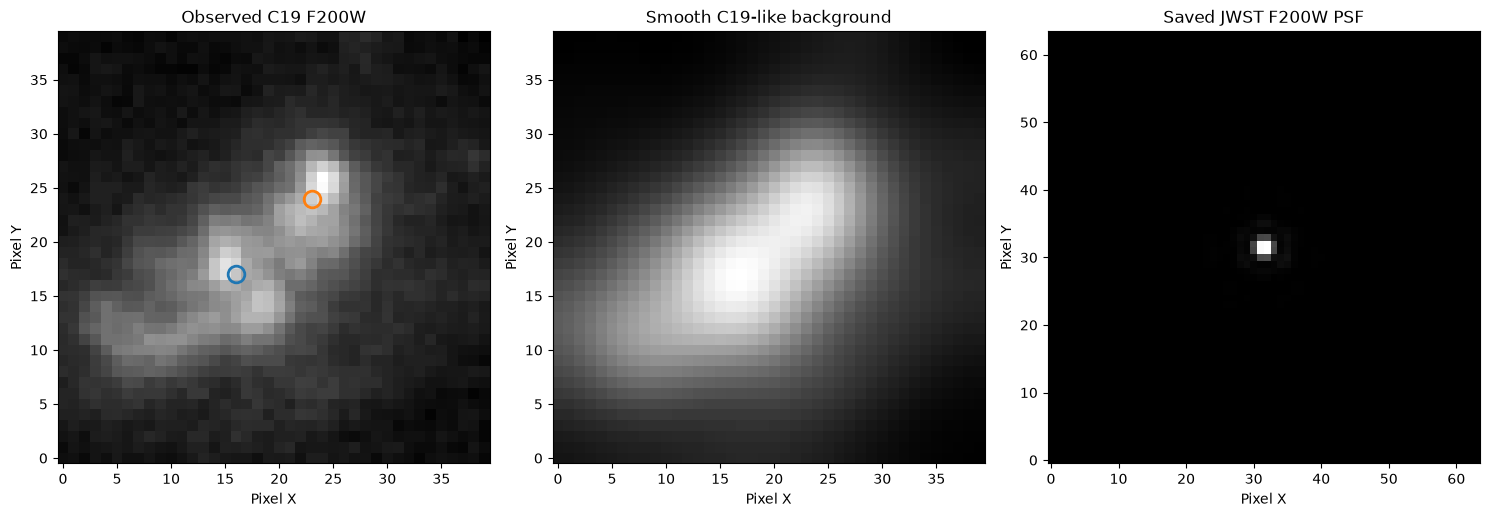

In [63]:
# ============================================================
# PHASE 4V — STEP 1
# LOAD SAVED F200W PSF AND PREPARE INJECTION TEST
# ============================================================

# ============================================================
# PHASE 4V — STEP 1
# LOAD SAVED F200W PSF AND PREPARE INJECTION TEST
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy.ndimage import gaussian_filter

print("=" * 60)
print("PHASE 4V — CONTROLLED PSF INJECTION / RECOVERY TEST")
print("=" * 60)

# ------------------------------------------------------------
# Saved PSF
# ------------------------------------------------------------

psf_file = (
    "/home/glenn/Projects/CosmicIntelligenceLab/"
    "data/processed/psf/"
    "jwst_nircam_f200w_detector_psf.fits"
)

if not os.path.exists(psf_file):
    raise FileNotFoundError(psf_file)

with fits.open(psf_file) as hdul:
    psf = np.asarray(
        hdul[0].data,
        dtype=float
    )

# Normalize
psf = np.maximum(psf, 0)
psf /= psf.sum()

print("\nSaved PSF loaded:")
print("Shape          :", psf.shape)
print("Normalized sum :", psf.sum())
print("Maximum        :", psf.max())


# ------------------------------------------------------------
# JW06541 F200W science image
# ------------------------------------------------------------

jwst_file = (
    "/home/glenn/Projects/CosmicIntelligenceLab/"
    "data/raw/jwst/"
    "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

with fits.open(jwst_file) as hdul:
    science = np.asarray(
        hdul["SCI"].data,
        dtype=float
    )


# ------------------------------------------------------------
# Extract the same 40 × 40 region
# ------------------------------------------------------------

x0 = 3863
y0 = 298

observed = science[
    y0:y0 + 40,
    x0:x0 + 40
].copy()

print("\nObserved region:")
print("Shape:", observed.shape)


# ------------------------------------------------------------
# Known P1 / P2 positions
# ------------------------------------------------------------

p1 = np.array([16.0, 17.0])
p2 = np.array([23.0, 24.0])

pixel_scale = 0.03123

separation_pixels = np.linalg.norm(
    p2 - p1
)

separation_arcsec = (
    separation_pixels *
    pixel_scale
)

print("\nKnown source geometry:")
print("P1:", p1)
print("P2:", p2)
print(
    f"Separation: {separation_pixels:.4f} pixels"
)
print(
    f"Separation: {separation_arcsec:.4f} arcsec"
)


# ------------------------------------------------------------
# Background
# ------------------------------------------------------------

background = 0.148668

observed_sub = observed - background


# ------------------------------------------------------------
# Build smooth C19-like background
# ------------------------------------------------------------

smooth_background = gaussian_filter(
    observed_sub,
    sigma=3.0
)

smooth_background = np.maximum(
    smooth_background,
    0
)


# ------------------------------------------------------------
# P1/P2 observed peak ratio
# ------------------------------------------------------------

p1_peak = 0.380685
p2_peak = 0.380511

peak_ratio = p2_peak / p1_peak

print("\nObserved peak ratio:")
print(
    f"P2 / P1 = {peak_ratio:.6f}"
)


# ------------------------------------------------------------
# Display the setup
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    observed,
    origin="lower",
    cmap="gray"
)

axes[0].plot(
    p1[0],
    p1[1],
    marker="o",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

axes[0].plot(
    p2[0],
    p2[1],
    marker="o",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

axes[0].set_title(
    "Observed C19 F200W"
)

axes[1].imshow(
    smooth_background,
    origin="lower",
    cmap="gray"
)

axes[1].set_title(
    "Smooth C19-like background"
)

axes[2].imshow(
    psf,
    origin="lower",
    cmap="gray"
)

axes[2].set_title(
    "Saved JWST F200W PSF"
)

for ax in axes:
    ax.set_xlabel("Pixel X")
    ax.set_ylabel("Pixel Y")

plt.tight_layout()
plt.show()

PHASE 4V — TWO-SOURCE PSF INJECTION

Injected sources:
P1 = (16.0, 17.0)
P2 = (23.0, 24.0)

Injected flux ratio P2/P1 = 1.000000
Measured central-pixel ratio = 0.969369

Source separation = 9.8995 pixels
Angular separation = 0.3092 arcsec


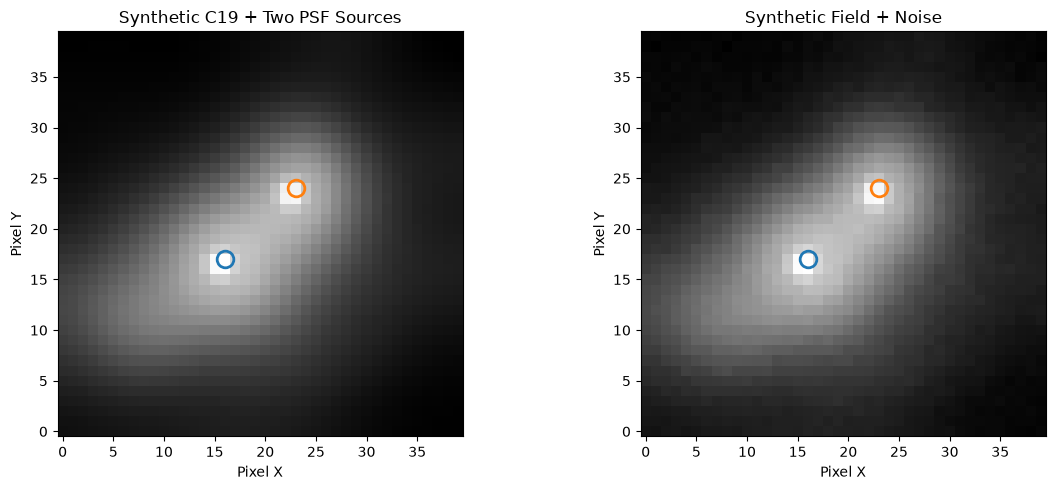

In [64]:
# ============================================================
# PHASE 4V — STEP 2
# INJECT TWO KNOWN F200W POINT SOURCES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

print("=" * 60)
print("PHASE 4V — TWO-SOURCE PSF INJECTION")
print("=" * 60)

# ------------------------------------------------------------
# Known source positions
# ------------------------------------------------------------

p1 = np.array([16.0, 17.0])
p2 = np.array([23.0, 24.0])

# Equal injected source strengths
flux_p1 = 1.0
flux_p2 = 1.0

# ------------------------------------------------------------
# Build 40 x 40 synthetic field
# ------------------------------------------------------------

ny, nx = 40, 40

yy, xx = np.indices((ny, nx))

# ------------------------------------------------------------
# Smooth galaxy background
#
# Use the previously extracted C19 background as the
# underlying extended morphology.
# ------------------------------------------------------------

background_model = smooth_background.copy()

# Normalize background to a convenient scale
background_model -= background_model.min()

if background_model.max() > 0:
    background_model /= background_model.max()

# Give the galaxy background a realistic relative amplitude
background_model *= 0.35

# ------------------------------------------------------------
# Function to inject a detector-sampled PSF
# ------------------------------------------------------------

def inject_psf(field, psf, x, y, amplitude):
    """
    Inject a detector-sampled PSF into a 2-D image.

    x, y are image coordinates in pixels.
    """

    result = field.copy()

    psf_size = psf.shape[0]
    half = psf_size // 2

    ix = int(round(x))
    iy = int(round(y))

    # PSF is much larger than the 40x40 region.
    # Extract the portion that overlaps the image.

    x1 = max(0, ix - half)
    x2 = min(nx, ix + half)

    y1 = max(0, iy - half)
    y2 = min(ny, iy + half)

    psf_x1 = half - (ix - x1)
    psf_x2 = psf_x1 + (x2 - x1)

    psf_y1 = half - (iy - y1)
    psf_y2 = psf_y1 + (y2 - y1)

    result[y1:y2, x1:x2] += (
        amplitude *
        psf[
            psf_y1:psf_y2,
            psf_x1:psf_x2
        ]
    )

    return result


# ------------------------------------------------------------
# Create synthetic field
# ------------------------------------------------------------

synthetic = background_model.copy()

synthetic = inject_psf(
    synthetic,
    psf,
    p1[0],
    p1[1],
    flux_p1
)

synthetic = inject_psf(
    synthetic,
    psf,
    p2[0],
    p2[1],
    flux_p2
)


# ------------------------------------------------------------
# Add a small amount of Gaussian noise
# ------------------------------------------------------------

rng = np.random.default_rng(42)

noise_sigma = 0.003

synthetic_noisy = (
    synthetic +
    rng.normal(
        0,
        noise_sigma,
        synthetic.shape
    )
)


# ------------------------------------------------------------
# Measure injected peaks
# ------------------------------------------------------------

p1_x = int(round(p1[0]))
p1_y = int(round(p1[1]))

p2_x = int(round(p2[0]))
p2_y = int(round(p2[1]))

peak1 = synthetic_noisy[p1_y, p1_x]
peak2 = synthetic_noisy[p2_y, p2_x]

print("\nInjected sources:")
print(
    f"P1 = ({p1[0]:.1f}, {p1[1]:.1f})"
)
print(
    f"P2 = ({p2[0]:.1f}, {p2[1]:.1f})"
)

print(
    f"\nInjected flux ratio P2/P1 = "
    f"{flux_p2 / flux_p1:.6f}"
)

print(
    f"Measured central-pixel ratio = "
    f"{peak2 / peak1:.6f}"
)

print(
    f"\nSource separation = "
    f"{np.linalg.norm(p2-p1):.4f} pixels"
)

print(
    f"Angular separation = "
    f"{np.linalg.norm(p2-p1)*0.03123:.4f} arcsec"
)


# ------------------------------------------------------------
# Display synthetic field
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].imshow(
    synthetic,
    origin="lower",
    cmap="gray"
)

axes[0].plot(
    p1[0],
    p1[1],
    marker="o",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

axes[0].plot(
    p2[0],
    p2[1],
    marker="o",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

axes[0].set_title(
    "Synthetic C19 + Two PSF Sources"
)

axes[1].imshow(
    synthetic_noisy,
    origin="lower",
    cmap="gray"
)

axes[1].plot(
    p1[0],
    p1[1],
    marker="o",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

axes[1].plot(
    p2[0],
    p2[1],
    marker="o",
    markersize=12,
    markerfacecolor="none",
    markeredgewidth=2
)

axes[1].set_title(
    "Synthetic Field + Noise"
)

for ax in axes:
    ax.set_xlabel("Pixel X")
    ax.set_ylabel("Pixel Y")

plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# PHASE 4V — STEP 3
# BLIND RECOVERY OF THE TWO INJECTED SOURCES
# ============================================================

from scipy.optimize import least_squares
from scipy.signal import fftconvolve

print("=" * 60)
print("PHASE 4V — BLIND TWO-SOURCE RECOVERY")
print("=" * 60)

# ------------------------------------------------------------
# PSF centered in a convenient kernel
# ------------------------------------------------------------

psf_kernel = psf / psf.sum()

# ------------------------------------------------------------
# Coordinate grid
# ------------------------------------------------------------

yy, xx = np.indices(synthetic_noisy.shape)


# ------------------------------------------------------------
# Gaussian component
# ------------------------------------------------------------

def gaussian_2d(
    x,
    y,
    amplitude,
    x0,
    y0,
    sigma_x,
    sigma_y
):
    return amplitude * np.exp(
        -(
            ((x - x0) ** 2) /
            (2 * sigma_x ** 2)
            +
            ((y - y0) ** 2) /
            (2 * sigma_y ** 2)
        )
    )


# ------------------------------------------------------------
# PSF convolution
# ------------------------------------------------------------

def convolve_model(model):
    return fftconvolve(
        model,
        psf_kernel,
        mode="same"
    )


# ------------------------------------------------------------
# One-component model
# ------------------------------------------------------------

def model_one(params):

    amplitude, x0, y0, sx, sy = params

    source = gaussian_2d(
        xx,
        yy,
        amplitude,
        x0,
        y0,
        sx,
        sy
    )

    return background_model + convolve_model(source)


# ------------------------------------------------------------
# Two-component model
# ------------------------------------------------------------

def model_two(params):

    (
        a1, x1, y1, sx1, sy1,
        a2, x2, y2, sx2, sy2
    ) = params

    source1 = gaussian_2d(
        xx,
        yy,
        a1,
        x1,
        y1,
        sx1,
        sy1
    )

    source2 = gaussian_2d(
        xx,
        yy,
        a2,
        x2,
        y2,
        sx2,
        sy2
    )

    return (
        background_model
        + convolve_model(source1 + source2)
    )


# ------------------------------------------------------------
# Residual functions
# ------------------------------------------------------------

def residual_one(params):
    return (
        model_one(params) -
        synthetic_noisy
    ).ravel()


def residual_two(params):
    return (
        model_two(params) -
        synthetic_noisy
    ).ravel()


# ------------------------------------------------------------
# Initial guesses
#
# NOTE:
# We deliberately use approximate positions rather than
# the exact injected positions.
# ------------------------------------------------------------

p0_one = [
    1.5,
    19.0,
    20.0,
    5.0,
    5.0
]

p0_two = [
    1.0, 15.0, 16.0, 4.0, 4.0,
    1.0, 24.0, 25.0, 4.0, 4.0
]


# ------------------------------------------------------------
# Bounds
# ------------------------------------------------------------

lower_one = [
    0.0,
    0.0,
    0.0,
    0.5,
    0.5
]

upper_one = [
    10.0,
    39.0,
    39.0,
    20.0,
    20.0
]


lower_two = [
    0.0, 0.0, 0.0, 0.5, 0.5,
    0.0, 0.0, 0.0, 0.5, 0.5
]

upper_two = [
    10.0, 39.0, 39.0, 20.0, 20.0,
    10.0, 39.0, 39.0, 20.0, 20.0
]


# ------------------------------------------------------------
# Fit one component
# ------------------------------------------------------------

fit_one = least_squares(
    residual_one,
    p0_one,
    bounds=(lower_one, upper_one),
    max_nfev=3000
)

# ------------------------------------------------------------
# Fit two components
# ------------------------------------------------------------

fit_two = least_squares(
    residual_two,
    p0_two,
    bounds=(lower_two, upper_two),
    max_nfev=5000
)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

rss_one = np.sum(
    fit_one.fun ** 2
)

rss_two = np.sum(
    fit_two.fun ** 2
)

n = synthetic_noisy.size

k_one = len(fit_one.x)
k_two = len(fit_two.x)

aic_one = (
    n * np.log(rss_one / n)
    + 2 * k_one
)

aic_two = (
    n * np.log(rss_two / n)
    + 2 * k_two
)

bic_one = (
    n * np.log(rss_one / n)
    + k_one * np.log(n)
)

bic_two = (
    n * np.log(rss_two / n)
    + k_two * np.log(n)
)


# ------------------------------------------------------------
# Extract recovered positions
# ------------------------------------------------------------

x1_rec = fit_two.x[1]
y1_rec = fit_two.x[2]

x2_rec = fit_two.x[6]
y2_rec = fit_two.x[7]

recovered_sep = np.sqrt(
    (x2_rec - x1_rec) ** 2
    +
    (y2_rec - y1_rec) ** 2
)

recovered_sep_arcsec = (
    recovered_sep * 0.03123
)


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("\n--- ONE-COMPONENT RECOVERY ---")

print(
    f"Center = "
    f"({fit_one.x[1]:.3f}, "
    f"{fit_one.x[2]:.3f})"
)

print(
    f"Sigma = "
    f"({fit_one.x[3]:.3f}, "
    f"{fit_one.x[4]:.3f})"
)

print(
    f"RSS = {rss_one:.6e}"
)

print(
    f"AIC = {aic_one:.3f}"
)

print(
    f"BIC = {bic_one:.3f}"
)


print("\n--- TWO-COMPONENT RECOVERY ---")

print(
    f"Component 1 center = "
    f"({x1_rec:.3f}, {y1_rec:.3f})"
)

print(
    f"Component 2 center = "
    f"({x2_rec:.3f}, {y2_rec:.3f})"
)

print(
    f"Recovered separation = "
    f"{recovered_sep:.4f} pixels"
)

print(
    f"Recovered separation = "
    f"{recovered_sep_arcsec:.4f} arcsec"
)

print(
    f"RSS = {rss_two:.6e}"
)

print(
    f"AIC = {aic_two:.3f}"
)

print(
    f"BIC = {bic_two:.3f}"
)


print("\n--- RECOVERY IMPROVEMENT ---")

print(
    f"RSS reduction = "
    f"{100 * (rss_one-rss_two)/rss_one:.2f}%"
)

print(
    f"Delta AIC = "
    f"{aic_one-aic_two:.3f}"
)

print(
    f"Delta BIC = "
    f"{bic_one-bic_two:.3f}"
)

PHASE 4V — BLIND TWO-SOURCE RECOVERY

--- ONE-COMPONENT RECOVERY ---
Center = (22.002, 22.985)
Sigma = (0.500, 0.500)
RSS = 6.545407e-02
AIC = -16156.665
BIC = -16129.776

--- TWO-COMPONENT RECOVERY ---
Component 1 center = (14.995, 15.996)
Component 2 center = (22.008, 22.987)
Recovered separation = 9.9027 pixels
Recovered separation = 0.3093 arcsec
RSS = 1.576891e-02
AIC = -18423.958
BIC = -18370.181

--- RECOVERY IMPROVEMENT ---
RSS reduction = 75.91%
Delta AIC = 2267.293
Delta BIC = 2240.404
